# Recovering the series from the composition — and the channel taxonomy

**Question.** E1 splits the water every link carries, hour by hour, by where it ends: each district's consumers, a
filling tank, a reservoir. How much of a link's measured flow can be rebuilt from the **districts' demand** with that
split — and does that still hold when a district drifts? This is the quality check of the mixture descriptor (a
mixture label assumes the flow is a mixture of the districts' demand), and it says, per class, what a mixture can
and cannot carry. Second part: the **channel taxonomy** of every (link, drifting district) cell.

| § | question | reads / runs |
|---|---|---|
| pass | E1 hour by hour on the no-drift city (init + every final window) and on every drift world (final); mixture fit on init | 1 no-drift simulation per partition (cached); stored drift flows |
| gates | the no-drift city is epanet_gt's; E1 closes every hour and equals epanet_gt's window shares; branches recover exactly | — |
| R | recovery quality per class, window and model; per drift world; placed sensors | `recovery` |
| R · gallery / widget | best / median / worst link per class; any link, any window, saved weeks | `weeks__*` |
| D | does the no-drift mixture predict the drift's change? | `recovery_delta` |
| C | composition of every link with reservoir / unaccounted apart; hour-of-week swing of every link | `composition_all` |
| X | channel class of every cell (S and Nr); recovery and β by class | `taxonomy` |

Results stay per partition and per drift world; pooled panels are labelled as such. Reads epanet_gt's outputs
(labels, gt_run.json, e1_composition, series); its engine code is not touched.

In [1]:
%matplotlib inline
import warnings, logging, sys, pathlib, json, datetime, time, copy, ctypes, tempfile
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import networkx as nx
import ipywidgets as ipw
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

REPO = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "fedwater").is_dir()), None)
assert REPO is not None, "run this from inside the fedwater repo"
LAB_DIR = REPO / "notebooks" / "fedwater_lab_refactor"     # adjust to your layout
for p in (REPO / "src", LAB_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))
import wntr
from wntr.epanet import toolkit
from wntr.network.io import write_inpfile
from fedwater.pipelines.network_prep.nodes import configure_network, apply_coupling     # read-only
from fedwater.pipelines.hydraulics.nodes import scratch_root, _remove, UNIT_BASE_SI
from fedwater.placement import signal_probe as sp
from fedwater.reporting import Atlas

warnings.filterwarnings("ignore")
logging.getLogger("kedro").setLevel(logging.WARNING)
pd.set_option("display.width", 230, "display.max_columns", 60, "display.max_rows", 300)
plt.rcParams.update({"figure.dpi": 90, "font.size": 8})

EXPERIMENTS = None              # None -> <project>/data/09_experiments
STUDY = "ky72_districting_all_districts"                    # set explicitly per network
ATLAS = Atlas(root=EXPERIMENTS)
WORLDS = ATLAS.worlds(STUDY, ok_only=True).reset_index(drop=True)
BASE = REPO / "notebooks" / "outputs" / STUDY
GT = BASE / "epanet_gt"                                       # reads: labels, gt_run.json, e1_composition, series
OUT = BASE / "epanet_recovery"
OUT.mkdir(parents=True, exist_ok=True)

FORCE_RERUN = False             # run the pass again even when a saved run matches this configuration
WEEKS_SAVED = 2                 # sample weeks kept per window for the gallery and the widget (first and last)

# definitions (FLOOR, CH_LO / CH_HI as in epanet_gt v3)
FLOOR = {"Nr": 0.05, "S": 0.25}
CH_LO, CH_HI = 1 / 3, 2 / 3     # E2 storage share: < CH_LO demand channel, > CH_HI storage channel, between: both
M_CARRY, M_TRACE = 0.05, 0.01   # E1 share of k's demand in the link's water: carrier >= M_CARRY; trace in [M_TRACE, M_CARRY)

# gates
GATE_NODRIFT = 1e-6             # re-simulated no-drift city vs epanet_gt's no-drift series (placed sensors), max rel
GATE_E1_ROW = 1e-9              # E1: destination shares of every node sum to 1, every hour
GATE_E1_CLOSE = 1e-6            # E1: the destination parts of every link sum to its |flow|, every hour (rel to max |q|)
GATE_E1_GT = {"no-drift": 1e-6, "drift": 1e-4}   # window shares vs epanet_gt (drift: stored flows, 2e-7 vs simulated)
GATE_BRANCH = 1e-3              # R1: branch |flow| = downstream demand, NRMSE

DW = pd.read_parquet(BASE / "dependence" / "worlds.parquet")                 # target windows (i0, i1, f0, f1)
LBg = pd.read_parquet(GT / "labels.parquet")                                  # epanet_gt labels (pumps, dead excluded)
E1g = pd.read_parquet(GT / "e1_composition.parquet")
GTRUN = json.loads((GT / "gt_run.json").read_text())
PLACED, PUMPS = GTRUN["PLACED"], GTRUN["PUMPS"]
for d_ in (LBg, E1g):
    d_["element"] = d_["element"].astype(str)
INFO = LBg.drop_duplicates(["districting", "element"])[["districting", "element", "home", "topo", "storage", "placed"]]
print(f"study {STUDY}: {len(WORLDS)} ok worlds  ->  {OUT}")

study ky72_districting_all_districts: 12 ok worlds  ->  c:\Users\arthu\USPy\10_Mestrado\fedWater\notebooks\outputs\ky72_districting_all_districts\epanet_recovery


### Harness

Verbatim from `epanet_gt` (toolkit step loop, model rebuild, demand injection, E1 algebra). New: `e1_hourly` (the same algebra, output kept per hour), the mixture fit / prediction and the scores.

In [2]:
EN_ELEV, EN_HEAD, EN_PRESSURE, EN_TANKVOL = 0, 10, 11, 24     # EPANET 2.2 node codes
EN_FLOW, EN_STATUS, EN_SETTING = 8, 11, 12                       # EPANET 2.2 link codes


def build_model(w):
    """The world's simulation model, rebuilt the way the pipeline builds it (network_prep, read-only):
    raw bundle .inp -> configure_network (solver, units, time) -> apply_coupling. Demand is injected later."""
    wn = copy.deepcopy(w.network_model)
    wn, _ = configure_network(wn, {"name": w.row["network"]}, w.params["hydraulics"], w.params["time"])
    wn, _ = apply_coupling(wn, w.catalog.load("districts"), w.params["coupling"], w.params["seed"])
    return wn


def set_horizon(wn, hours, hyd_step=3600):
    # duration only; pattern and report steps stay as configure_network pinned them (1 h)
    wn.options.time.duration = int(hours) * 3600
    wn.options.time.hydraulic_timestep = int(hyd_step)
    return wn


def inject_demand(wn, demand):
    """Verbatim convention of run_hydraulics: base 1 L/s, pattern = the series in L/s; junctions without a
    column are pinned to zero."""
    cols = [c for c in demand.columns if c != "month"]
    for node in cols:
        j = wn.get_node(node)
        wn.add_pattern(f"P{node}", demand[node].to_list())
        j.demand_timeseries_list[0].base_value = UNIT_BASE_SI
        j.demand_timeseries_list[0].pattern_name = f"P{node}"
    for node in set(wn.junction_name_list) - set(cols):
        slot = wn.get_node(node).demand_timeseries_list[0]
        slot.base_value, slot.pattern_name = 0.0, None
    return wn


def mediators(wn):
    # every pump, and every link a control acts on (pumps, level-controlled valves and pipes)
    out = set(wn.pump_name_list)
    for _, c in wn.controls():
        for a in c.actions():
            obj, attr = a.target()
            if attr in ("status", "setting") and getattr(obj, "name", None) in wn.link_name_list:
                out.add(obj.name)
    return sorted(out)


def simulate(wn, demand, hours, hyd_step=3600, pmin_nodes=None, dtype=np.float64):
    """EPANET 2.2 run through the toolkit step loop: every intermediate step of the solve is visited, the
    solution is the one EpanetSimulator computes. Returns, per hour h (t = 3600 h):
      snap   flows at t (what the stored data hold), L/s        avg  time-average over [t, t+1h), L/s
      med_status / med_setting  mediator links at t             on_frac  pumps' time-average open fraction
      tank_head, tank_vol at t; pmin = min pressure at t over pmin_nodes (default: junctions that carry demand —
      a zero-demand node such as a pump suction can sit below zero by design); switches per pump over all steps.
    Every run reports `completed` (the solve reached the horizon) and the EPANET warning codes it met
    (`warnings`: code -> number of solver steps; 1 = unbalanced/unconverged, 2 = disconnected nodes,
    3/4/5 = pumps/valves cannot deliver, 6 = negative pressures). An unconverged step under UNBALANCED STOP
    halts EPANET silently: hours after the halt would read zero, so `completed` must be checked."""
    wn = inject_demand(set_horizon(copy.deepcopy(wn), hours, hyd_step), demand.iloc[:hours])
    links, tanks, pumps = list(wn.link_name_list), list(wn.tank_name_list), list(wn.pump_name_list)
    meds = mediators(wn)
    if pmin_nodes is None:
        dcols = [c for c in demand.columns if c != "month"]
        pmin_nodes = [c for c in dcols if float(np.abs(demand[c].iloc[:hours]).max()) > 0]
    juncs = [j for j in pmin_nodes if j in set(wn.junction_name_list)] or list(wn.junction_name_list)
    d = Path(tempfile.mkdtemp(prefix="fedwater_e024_", dir=scratch_root()))
    t0 = time.time()
    try:
        inp = str(d / "run.inp")
        write_inpfile(wn, inp, units=wn.options.hydraulic.inpfile_units, version=2.2)
        en = toolkit.ENepanet(version=2.2)
        en.ENopen(inp, str(d / "run.rpt"), str(d / "run.bin"))
        li = [en.ENgetlinkindex(x) for x in links]
        pi = [en.ENgetlinkindex(x) for x in pumps]
        mi = [en.ENgetlinkindex(x) for x in meds]
        ti = [en.ENgetnodeindex(x) for x in tanks]
        ji = [en.ENgetnodeindex(x) for x in juncs]
        lib, prj, val = en.ENlib, en._project, ctypes.c_double()
        get_l, get_n = lib.EN_getlinkvalue, lib.EN_getnodevalue

        def lv(idx, code):
            out = np.empty(len(idx))
            for j, i in enumerate(idx):
                get_l(prj, i, code, ctypes.byref(val)); out[j] = val.value
            return out

        def nv(idx, code):
            out = np.empty(len(idx))
            for j, i in enumerate(idx):
                get_n(prj, i, code, ctypes.byref(val)); out[j] = val.value
            return out

        L, P, M, T = len(links), len(pumps), len(meds), len(tanks)
        snap, avg = np.zeros((hours, L), dtype), np.zeros((hours, L), dtype)
        acc, acc_h = np.zeros(L), 0                              # float64 accumulator of the current hour
        warn, t_end = Counter(), 0
        run_h, next_h = lib.EN_runH, lib.EN_nextH
        lT, lS = ctypes.c_long(), ctypes.c_long()
        on_frac, mstat, mset = np.zeros((hours, P)), np.zeros((hours, M)), np.zeros((hours, M))
        thead, tvol, pmin = np.zeros((hours, T)), np.zeros((hours + 1, T)), np.zeros(hours)
        switches, last, n_steps = np.zeros(P), None, 0
        en.ENopenH(); en.ENinitH(0)
        while True:
            code = run_h(prj, ctypes.byref(lT))
            if code >= 100:
                raise RuntimeError(f"EPANET error {code} at t = {lT.value} s")
            if code:
                warn[int(code)] += 1
            t = int(lT.value)
            t_end = t
            q = lv(li, EN_FLOW)
            st = lv(pi, EN_STATUS) if P else np.zeros(0)
            h = t // 3600
            if t % 3600 == 0 and h <= hours:
                if T:
                    tvol[h] = nv(ti, EN_TANKVOL)
                if h < hours:
                    snap[h] = q
                    if M:
                        mstat[h], mset[h] = lv(mi, EN_STATUS), lv(mi, EN_SETTING)
                    if T:
                        thead[h] = nv(ti, EN_HEAD)
                    pmin[h] = nv(ji, EN_PRESSURE).min()
            if last is not None:
                switches += st != last
            last = st
            code = next_h(prj, ctypes.byref(lS))
            if code >= 100:
                raise RuntimeError(f"EPANET error {code} after t = {t} s")
            dt = int(lS.value)
            if h < hours and dt > 0:
                if h != acc_h:
                    avg[acc_h] = acc / 3600.0
                    acc, acc_h = np.zeros(L), h
                acc += q * dt
                on_frac[h] += st * dt
            n_steps += 1
            if dt <= 0:
                break
        if acc_h < hours:
            avg[acc_h] = acc / 3600.0
        en.ENcloseH(); en.ENclose()
    finally:
        _remove(d)
    return {"links": links, "pumps": pumps, "meds": meds, "tanks": tanks, "snap": snap, "avg": avg,
            "completed": t_end >= hours * 3600, "t_end_h": t_end / 3600.0, "warnings": dict(warn),
            "on_frac": on_frac / 3600.0, "med_status": mstat, "med_setting": mset, "tank_head": thead,
            "tank_vol": tvol, "pmin": pmin, "switches": switches, "n_steps": n_steps,
            "seconds": time.time() - t0}

In [3]:
RUNLOG = []                                                        # every simulation of this notebook


def log_run(r, **meta):
    """Record a run's integrity (reached the horizon? unconverged steps?) and pass it through."""
    w = r.get("warnings", {})
    RUNLOG.append({**meta, "completed": bool(r["completed"]), "t_end_h": r["t_end_h"], "n_steps": r["n_steps"],
                   "unbalanced_steps": int(w.get(1, 0)), "warnings": json.dumps({str(k): v for k, v in w.items()}),
                   "seconds": round(r["seconds"], 1)})
    return r


def run_gate(section):
    """G-run: every simulation of `section` reached its horizon with no unconverged step."""
    rl = pd.DataFrame([x for x in RUNLOG if x.get("section") == section])
    if not len(rl):
        return {"gate": f"G-run {section}: completed, converged", "value": "no runs", "passed": False}
    bad = rl[~rl["completed"] | (rl["unbalanced_steps"] > 0)]
    return {"gate": f"G-run {section}: completed, converged", "value": f"{len(bad)} / {len(rl)} runs failing",
            "passed": bool(len(bad) == 0)}


def link_table(wn):
    rows = [(ln, wn.get_link(ln).start_node_name, wn.get_link(ln).end_node_name, type(wn.get_link(ln)).__name__)
            for ln in wn.link_name_list]
    return pd.DataFrame(rows, columns=["link", "start", "end", "link_type"]).set_index("link")


def branch_downstream(wn, LT):
    # exact downstream junction sets of bridge links whose downstream side has no source (as in epanet_poc)
    G = nx.Graph()
    for ln, r in LT.iterrows():
        G.add_edge(r["start"], r["end"])
    pairs = Counter(frozenset((r["start"], r["end"])) for _, r in LT.iterrows())
    sources = set(wn.tank_name_list) | set(wn.reservoir_name_list)
    out = {}
    for u, v in nx.bridges(G):
        e = frozenset((u, v))
        if pairs[e] > 1:
            continue
        G.remove_edge(u, v)
        cu = nx.node_connected_component(G, u)
        G.add_edge(u, v)
        cv = set(G.nodes) - cu
        su, sv = bool(cu & sources), bool(cv & sources)
        if su != sv:
            dn = cv if su else cu
            for ln, r in LT.iterrows():
                if frozenset((r["start"], r["end"])) == e:
                    out[ln] = dn
    return out


def profile(X, sd, lo):
    # weekly profile of every column of X (T x L) -> (L, 7 sd); a 1-D series -> (1, 7 sd)
    X = np.asarray(X, float)
    return np.atleast_2d(sp.weekly_profile(X if X.ndim > 1 else X[:, None], sd, step0=lo))


def zrows(A):
    # as dependence_compute: each row z-scored; constant rows -> NaN
    s = A.std(axis=1, keepdims=True)
    return (A - A.mean(axis=1, keepdims=True)) / np.where(s > 1e-12, s, np.nan)


def e1_destinations(F, Dm, LT, districts, node2d, tanks, reservoirs, hours, sd=24, eps=1e-9):
    """Flow-path destination decomposition (complete mixing at nodes, as EPANET's water quality model).

    Each hour: water leaving node n ends in a junction demand of district k, in a FILLING tank
    ("storage:<T>"), in a reservoir it flows back into ("reservoir:<R>"), or — where the hydraulic solution
    does not balance a node to solver precision — in "unaccounted" (the excess inflow of that node), so the
    accounting always closes and the solver imbalance is measured instead of silently losing water. With phi_n the destination shares of n's water and O_n its total outflow (edges + demand
    + tank sink):  O_n phi_n = demand_n e_{district(n)} + sink_n e_{storage(n)} + sum_{n->v} q phi_v.
    A link carries the shares of its downstream node. Solved as a sparse linear system (handles any flow
    pattern, not only acyclic ones). Accumulated flow-weighted over the given hours, overall and per
    hour-of-week. Returns (shares L x K, volume L, how_shares L x 7sd x K, row-sum deviation per hour).
    """
    from scipy.sparse import csr_matrix, diags
    from scipy.sparse.linalg import splu
    cols = [c for c in F.columns if c in LT.index]
    nodes = sorted(set(LT.loc[cols, "start"]) | set(LT.loc[cols, "end"]))
    ix = {n: i for i, n in enumerate(nodes)}
    dests = list(districts) + [f"storage:{t}" for t in tanks] + [f"reservoir:{r}" for r in reservoirs] + ["unaccounted"]
    di = {d: i for i, d in enumerate(dests)}
    st = LT.loc[cols, "start"].map(ix).to_numpy()
    en = LT.loc[cols, "end"].map(ix).to_numpy()
    jcols = [n for n in Dm.columns if n in ix]
    jidx = np.array([ix[n] for n in jcols])
    jdst = np.array([di.get(node2d.get(n), -1) for n in jcols])
    tix = [(ix[t], di[f"storage:{t}"]) for t in tanks if t in ix]
    rix = [(ix[r], di[f"reservoir:{r}"]) for r in reservoirs if r in ix]
    special = set(i for i, _ in tix) | set(i for i, _ in rix)
    junc_like = np.array([i not in special for i in range(len(nodes))])
    k_un = di["unaccounted"]
    N, K, L = len(nodes), len(dests), len(cols)
    Fv, Dv = F[cols].to_numpy(float), Dm[jcols].to_numpy(float)
    P = 7 * sd
    acc, vol = np.zeros((L, K)), np.zeros(L)
    acc_h, vol_h = np.zeros((L, P, K)), np.zeros((L, P))
    dev = []
    for t in hours:
        f, d = Fv[t], Dv[t]
        act = np.abs(f) > eps
        fwd = f > 0
        u = np.where(fwd, st, en)[act]
        v = np.where(fwd, en, st)[act]
        q = np.abs(f)[act]
        O = np.zeros(N)
        np.add.at(O, u, q)
        qin = np.zeros(N)
        np.add.at(qin, v, q)
        S = np.zeros((N, K))
        dn = np.zeros(N)
        dn[jidx] = d
        ok = jdst >= 0
        S[jidx[ok], jdst[ok]] += d[ok]
        O += dn
        for ti, tk in tix + rix:                                # a filling tank / receiving reservoir keeps water
            sink = max(qin[ti] - (O[ti] - dn[ti]), 0.0)
            S[ti, tk] += sink
            O[ti] += sink
        excess = np.where(junc_like, np.clip(qin - O, 0.0, None), 0.0)   # inflow a junction does not pass on
        S[:, k_un] += excess
        O += excess
        dead = O <= eps
        # a dead node (no outflow, no demand) has no outgoing edges, so its row is empty: diagonal 1, phi = 0
        A = diags(np.where(dead, 1.0, O)) - csr_matrix((q, (u, v)), shape=(N, N))
        Phi = splu(A.tocsc()).solve(S)                          # N x K
        rs = Phi.sum(axis=1)[~dead]
        dev.append(float(np.max(np.abs(rs - 1.0))) if len(rs) else 0.0)
        li = np.where(act)[0]
        contrib = q[:, None] * Phi[v]
        acc[li] += contrib
        vol[li] += q
        h = t % P
        acc_h[li, h] += contrib
        vol_h[li, h] += q
    with np.errstate(invalid="ignore", divide="ignore"):
        shares = acc / vol[:, None]
        how = acc_h / vol_h[:, :, None]
    return (pd.DataFrame(shares, index=cols, columns=dests), pd.Series(vol, index=cols),
            how, np.array(dev), dests)

In [4]:
def _cols(df):
    df.columns = [c if c == "month" else str(c) for c in df.columns]
    return df.reset_index(drop=True)


def load_target(m, g):
    """The study's worlds of partition m: demand, stored flows, model and the study's windows (as epanet_gt)."""
    out = []
    dwx = DW.set_index("world")
    for _, r in g.iterrows():
        w = ATLAS.world(r["sim_hash"])
        h8 = r["sim_hash"][:8]
        out.append({"k": r["drift_district"], "id": h8, "D": _cols(w.catalog.load("demand_series")),
                    "F": _cols(w.catalog.load("flows")), "wn": build_model(w),
                    "wI": (int(dwx.at[h8, "i0"]), int(dwx.at[h8, "i1"])),
                    "wF": (int(dwx.at[h8, "f0"]), int(dwx.at[h8, "f1"]))})
    dy = ATLAS.world(g.iloc[0]["sim_hash"]).catalog.load("districts")
    return out, dy, 24 // int(ATLAS.world(g.iloc[0]["sim_hash"]).params["time"].get("resolution_h", 1))


def splice(worlds, names, node2d):
    # the no-drift city: each district's demand from a world in which it does not drift (exact: gate G-E5a in epanet_gt)
    D0 = worlds[0]["D"].copy()
    cols = [c for c in D0.columns if c != "month"]
    for d in names:
        dc = [c for c in cols if node2d.get(c) == d]
        D0[dc] = next(x for x in worlds if x["k"] != d)["D"][dc].to_numpy()
    return D0


def e1_hourly(F, Dm, LT, districts, node2d, tanks, reservoirs, hours, keep="full", eps=1e-9):
    """E1 hour by hour. The algebra is verbatim from e1_destinations (validated in epanet_poc / epanet_gt); only the
    output differs: for every hour and link, the flow the link carries split by destination group
    [district_1 .. district_K, storage (filling tanks), reservoir, unaccounted].
    keep='full' -> Y (T, L, K+3);  keep='nd' -> only the non-demand part (storage + reservoir + unaccounted), Y (T, L).
    Also returns the window totals per group (L, K+3), the row-sum deviation per hour and the link order."""
    from scipy.sparse import csr_matrix, diags
    from scipy.sparse.linalg import splu
    districts = list(districts)
    cols = [c for c in F.columns if c in LT.index]
    nodes = sorted(set(LT.loc[cols, "start"]) | set(LT.loc[cols, "end"]))
    ix = {n: i for i, n in enumerate(nodes)}
    dests = districts + [f"storage:{t}" for t in tanks] + [f"reservoir:{r}" for r in reservoirs] + ["unaccounted"]
    di = {d: i for i, d in enumerate(dests)}
    K = len(districts)
    grp = np.zeros((len(dests), K + 3))
    for d, i in di.items():
        grp[i, districts.index(d) if d in districts else K if d.startswith("storage:") else
            K + 1 if d.startswith("reservoir:") else K + 2] = 1.0
    st = LT.loc[cols, "start"].map(ix).to_numpy()
    en = LT.loc[cols, "end"].map(ix).to_numpy()
    jcols = [n for n in Dm.columns if n in ix]
    jidx = np.array([ix[n] for n in jcols])
    jdst = np.array([di.get(node2d.get(n), -1) for n in jcols])
    tix = [(ix[t], di[f"storage:{t}"]) for t in tanks if t in ix]
    rix = [(ix[r], di[f"reservoir:{r}"]) for r in reservoirs if r in ix]
    special = set(i for i, _ in tix) | set(i for i, _ in rix)
    junc_like = np.array([i not in special for i in range(len(nodes))])
    k_un = di["unaccounted"]
    N, KD, L = len(nodes), len(dests), len(cols)
    Fv, Dv = F[cols].to_numpy(float), Dm[jcols].to_numpy(float)
    hours = list(hours)
    Y = np.zeros((len(hours), L, K + 3), np.float32) if keep == "full" else np.zeros((len(hours), L), np.float32)
    tot, dev = np.zeros((L, K + 3)), []
    for it, t in enumerate(hours):
        f, d = Fv[t], Dv[t]
        act = np.abs(f) > eps
        fwd = f > 0
        u = np.where(fwd, st, en)[act]
        v = np.where(fwd, en, st)[act]
        q = np.abs(f)[act]
        O = np.zeros(N)
        np.add.at(O, u, q)
        qin = np.zeros(N)
        np.add.at(qin, v, q)
        S = np.zeros((N, KD))
        dn = np.zeros(N)
        dn[jidx] = d
        ok = jdst >= 0
        S[jidx[ok], jdst[ok]] += d[ok]
        O += dn
        for ti, tk in tix + rix:
            sink = max(qin[ti] - (O[ti] - dn[ti]), 0.0)
            S[ti, tk] += sink
            O[ti] += sink
        excess = np.where(junc_like, np.clip(qin - O, 0.0, None), 0.0)
        S[:, k_un] += excess
        O += excess
        dead = O <= eps
        A = diags(np.where(dead, 1.0, O)) - csr_matrix((q, (u, v)), shape=(N, N))
        Phi = splu(A.tocsc()).solve(S)
        rs = Phi.sum(axis=1)[~dead]
        dev.append(float(np.max(np.abs(rs - 1.0))) if len(rs) else 0.0)
        li = np.where(act)[0]
        contrib = (q[:, None] * Phi[v]) @ grp                    # n_act x (K+3)
        tot[li] += contrib
        if keep == "full":
            Y[it, li] = contrib
        else:
            Y[it, li] = contrib[:, K:].sum(axis=1)
    return cols, Y, tot, np.array(dev)


def fit_mixture(Y, Dd, hours, P):
    """Mixture weights from the no-drift init window. Y (T, L, K+3) per-hour destination flows, Dd (T, K) district
    demand.  a_static[s, d] = sum_t y_sd(t) / sum_t D_d(t);  a_how[s, h, d] = the same over the hours with
    hour-of-week h — the share of district d's demand that flows through link s (overall / at that hour of the week)."""
    K = Dd.shape[1]
    den = Dd.sum(axis=0)
    a_static = Y[:, :, :K].sum(axis=0) / np.where(den > 0, den, np.nan)
    h = np.asarray(hours) % P
    a_how = np.full((Y.shape[1], P, K), np.nan)
    for hh in range(P):
        sel = h == hh
        if sel.any():
            dh = Dd[sel].sum(axis=0)
            a_how[:, hh, :] = Y[sel][:, :, :K].sum(axis=0) / np.where(dh > 0, dh, np.nan)
    return np.nan_to_num(a_static), np.nan_to_num(a_how)


def predict(a_static, a_how, Dd, hours, P):
    # R2 (fixed mixture) and R3 (mixture by hour of week) of every link's |flow|, from the districts' demand
    R2 = Dd @ a_static.T
    h = np.asarray(hours) % P
    R3 = np.empty_like(R2)
    for hh in np.unique(h):
        sel = h == hh
        R3[sel] = Dd[sel] @ a_how[:, hh, :].T
    return R2, R3


def scores(y, yhat, sd, lo):
    """Per column: NRMSE = ||y - yhat|| / ||y - mean y|| (0 perfect, 1 = no better than the mean; NaN for constant y),
    bias share = |mean(y - yhat)| / mean|y|, and rho_shape = correlation of the z-scored weekly profiles (what a client
    sees after per-client scaling)."""
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    e = y - yhat
    den = np.sqrt(((y - y.mean(axis=0)) ** 2).sum(axis=0))
    nrmse = np.sqrt((e ** 2).sum(axis=0)) / np.where(den > 1e-9, den, np.nan)
    my = np.abs(y).mean(axis=0)
    bias = np.abs(e.mean(axis=0)) / np.where(my > 1e-9, my, np.nan)
    rho = np.nanmean(zrows(profile(y, sd, lo)) * zrows(profile(yhat, sd, lo)), axis=1)
    return nrmse, bias, rho


def delta_scores(dy, dyhat):
    """Change under the drift: NRMSE_d = ||dy - dyhat|| / ||dy|| (0 perfect, 1 = no better than predicting no change)
    and the correlation of the hourly changes."""
    dy, dyhat = np.asarray(dy, float), np.asarray(dyhat, float)
    n = np.sqrt((dy ** 2).sum(axis=0))
    nrmse = np.sqrt(((dy - dyhat) ** 2).sum(axis=0)) / np.where(n > 1e-9, n, np.nan)
    a, b = dy - dy.mean(axis=0), dyhat - dyhat.mean(axis=0)
    sa, sb = np.sqrt((a ** 2).sum(axis=0)), np.sqrt((b ** 2).sum(axis=0))
    corr = (a * b).sum(axis=0) / np.where((sa > 1e-9) & (sb > 1e-9), sa * sb, np.nan)
    return nrmse, corr


GROUPS = ["branch", "loop · demand-class", "loop · storage-class", "source_bridge · demand-class",
          "source_bridge · storage-class", "other"]


def group_of(topo, storage):
    if topo == "branch":
        return "branch"
    if topo in ("loop", "source_bridge"):
        cls = "?" if pd.isna(storage) else ("storage" if bool(storage) else "demand")
        return f"{topo} · {cls}-class"
    return "other"


INFO["group"] = [group_of(t, s) for t, s in zip(INFO["topo"], INFO["storage"])]

### Definitions

$y_s(t)=|q_s(t)|$, the link's flow magnitude (E1 works on magnitudes; the share of hours whose sign differs from
the mean direction is reported as `flip_share`). E1 gives, every hour, $y_s(t)=\sum_d y_{s,d}(t)+y_{s,\text{tank}}(t)
+y_{s,\text{res}}(t)+y_{s,\text{un}}(t)$, with $y_{s,d}(t)$ the part of the flow that ends in district $d$'s consumers.
$D_d(t)$ = district $d$'s demand; $h(t)$ = hour of the week. Fit on the no-drift init window $I$:

| model | $\hat y_s(t)$ | weights | reads as |
|---|---|---|---|
| R1 (branches) | $\sum_{n\in\text{down}(s)}D_n(t)$ | none (topology) | exact by physics — a gate |
| R2 | $\sum_d a_{s,d}D_d(t)$ | $a_{s,d}=\sum_{I}y_{s,d}/\sum_{I}D_d$ | a fixed share of each district's demand passes the link |
| R3 | $\sum_d a_{s,d,h(t)}D_d(t)$ | the same per hour of the week | the routing follows the weekly pump / tank schedule |
| R4 | R3 $+\,y_{s,\text{tank}}+y_{s,\text{res}}+y_{s,\text{un}}$ (observed) | R3 | what is left once the tank-bound water is known (upper bound) |

Scores per link and window: $\text{NRMSE}=\lVert y-\hat y\rVert/\lVert y-\bar y\rVert$ (0 exact, 1 = no better than
the link's mean); bias $=|\overline{y-\hat y}|/\overline{|y|}$; $\rho_\text{shape}$ = correlation of the z-scored weekly
profiles of $y$ and $\hat y$ (what a client sees after per-client scaling).
Windows: **init** (in sample), **final, no drift** (the same city, outside the fitting window — one per drift world's
window), **final, k drifts** (the drift world with $D^{(k)}$ and the no-drift weights).

Under the drift (world $k$, final window): $\Delta y=y^{(k)}-y^{(0)}$, predicted $\Delta\hat y=\hat y(D^{(k)})-\hat y(D^{(0)})$
($=a_{s,k}\Delta D_k$ for R2); $\text{NRMSE}_\Delta=\lVert\Delta y-\Delta\hat y\rVert/\lVert\Delta y\rVert$ (1 = no better
than predicting no change); exact magnitude gain $g=\langle\Delta y,\Delta D_k\rangle/\lVert\Delta D_k\rVert^2$ against the
mixture's $a_{s,k}$.

**Swing** of a link: $q_{95}-q_{05}$ over the 168 hours of the week of its own share (renormalised over districts, as
epanet_gt M2; and raw, tank water in the denominator).

| gate | rule |
|---|---|
| G-R0 / R1 | no-drift run completed and converged; equal to epanet_gt's no-drift city on the placed sensors (≤ 1e-6) |
| G-R2 / R3 | E1 node shares sum to 1 every hour (≤ 1e-9); a link's destination parts sum to its \|flow\| every hour (≤ 1e-6) |
| G-R4 | window shares equal epanet_gt's E1 (no drift ≤ 1e-6; drift ≤ 1e-4: stored flows vs epanet_gt's re-simulation) |
| G-R5 | R1 recovers every branch (NRMSE ≤ 1e-4) |

In [5]:
# the pass: per partition, the no-drift city (one simulation, cached), E1 hour by hour, the mixture fit on the init
# window and its scores on every window; written to OUT and reused when the configuration matches
RUN_CFG = json.loads(json.dumps({"study": STUDY, "worlds": sorted(WORLDS["sim_hash"].astype(str)),
                                 "WEEKS_SAVED": WEEKS_SAVED, "version": 1}))
RUN_MANIFEST = OUT / "recovery_run.json"
TABLES = ("recovery", "recovery_delta", "composition_all", "rec_gates")
PARTS = sorted(WORLDS["districting"].unique())


def _saved_run():
    if FORCE_RERUN or not RUN_MANIFEST.exists():
        return None
    man = json.loads(RUN_MANIFEST.read_text())
    if man["config"] != RUN_CFG:
        print("saved run not reused: configuration differs"); return None
    need = [OUT / f"{t}.parquet" for t in TABLES] + [OUT / f"{p}__{m}.npz" for m in PARTS for p in ("fit", "weeks")]
    miss = [x.name for x in need if not x.exists()]
    if miss:
        print(f"saved run not reused: files missing {miss}"); return None
    return man


def weeks_of(a, b, P, n):
    # start hours of n sample weeks in [a, b): the first and the last full week (n = 2), first only (n = 1)
    starts = [a, b - P][:max(n, 1)] if b - a >= 2 * P else [a]
    return sorted(set(starts))


man = _saved_run()
if man is None:
    REC, DEL, COMP, GATES = [], [], [], []
    _t0 = time.time()
    for m, g in WORLDS.groupby("districting"):
        worlds, dy, sd = load_target(m, g)
        names = list(dy["districts"])
        node2d = {str(n): d for d, ns in dy["districts"].items() for n in ns}
        H, P, K = len(worlds[0]["D"]), 7 * sd, len(names)
        D0 = splice(worlds, names, node2d)
        jcols = [c for c in D0.columns if c != "month"]
        kc = {d: [c for c in jcols if node2d.get(c) == d] for d in names}
        wn0 = worlds[0]["wn"]
        LT = link_table(wn0)
        DOWN = branch_downstream(wn0, LT)
        tanks, resv = list(wn0.tank_name_list), list(wn0.reservoir_name_list)
        dd_of = lambda D: np.stack([D[kc[d]].sum(axis=1).to_numpy(np.float64) for d in names], 1).astype(np.float32)
        Dd0 = dd_of(D0)

        # ---- the no-drift city: simulated once, cached with its run record ---------------------------------
        cache = OUT / f"nodrift__{m}.npz"
        if cache.exists() and not FORCE_RERUN:
            z = np.load(cache)
            F0 = pd.DataFrame(z["Q"], columns=[str(x) for x in z["links"]])
            run_ok, run_note = bool(z["completed"]) and int(z["unbalanced"]) == 0, "cached"
        else:
            r0 = log_run(simulate(wn0, D0, H, dtype=np.float32), section="pass", districting=m, run="no-drift")
            F0 = pd.DataFrame(r0["snap"], columns=r0["links"])
            unb = int(r0["warnings"].get(1, 0))
            np.savez_compressed(cache, links=np.array(r0["links"]), Q=r0["snap"], completed=r0["completed"], unbalanced=unb)
            run_ok, run_note = bool(r0["completed"]) and unb == 0, f"{r0['seconds']:.0f} s"
            del r0
        GATES.append({"districting": m, "gate": "G-R0 no-drift run completed, converged", "value": run_note, "passed": run_ok})
        zg = np.load(GT / "series" / f"{m}__nodrift.npz")
        gl = [str(x) for x in zg["links"]]
        rel = float(np.abs(F0[gl].to_numpy(float) - zg["Q"].astype(float)).max() / max(np.abs(zg["Q"]).max(), 1e-12)) if gl else 0.0
        GATES.append({"districting": m, "gate": "G-R1 no-drift city = epanet_gt's (placed sensors)", "value": f"{rel:.1e}",
                      "passed": rel <= GATE_NODRIFT})

        # ---- init window (no drift): E1 per hour, the mixture fit, in-sample scores --------------------------
        i0, i1 = worlds[0]["wI"]
        hI = list(range(i0, i1))
        cols, YI, totI, devI = e1_hourly(F0, D0[jcols], LT, names, node2d, tanks, resv, hI, "full")
        F0 = F0[cols]
        Q0 = F0.to_numpy(float)
        yI = np.abs(Q0[i0:i1])
        close = float(np.abs(YI.sum(axis=-1) - yI).max() / max(yI.max(), 1e-12))
        o = np.sign(Q0[i0:i1].mean(axis=0))
        flip = ((np.sign(Q0[i0:i1]) * np.where(o == 0, 1, o) < 0) & (yI > 1e-9)).mean(axis=0)
        a_s, a_h = fit_mixture(YI, Dd0[i0:i1], hI, P)
        R2, R3 = predict(a_s, a_h, Dd0[i0:i1], hI, P)
        ndI = YI[:, :, K:].sum(axis=-1)
        br = [j for j, c in enumerate(cols) if c in DOWN]

        def add(world, window, k, model, y, yhat, lo, idx=None):
            idx = np.arange(len(cols)) if idx is None else np.asarray(idx)
            if not len(idx):
                return
            n_, b_, r_ = scores(y[:, idx], yhat[:, idx] if yhat.shape[1] != len(idx) else yhat, sd, lo)
            REC.append(pd.DataFrame({"districting": m, "world": world, "window": window, "k": k, "model": model,
                                     "element": [cols[j] for j in idx], "nrmse": n_, "bias": b_, "rho_shape": r_}))

        def branch_pred(D, a, b):
            return np.stack([D[[n for n in jcols if n in DOWN[cols[j]]]].sum(axis=1).to_numpy(float)[a:b] for j in br], 1) \
                if br else np.zeros((b - a, 0))

        for mod, yh in (("R2", R2), ("R3", R3), ("R4", R3 + ndI)):
            add("no-drift", "init (fit)", None, mod, yI, yh, i0)
        add("no-drift", "init (fit)", None, "R1", yI, branch_pred(D0, i0, i1), i0, br)

        # composition of every link (no drift, init) with reservoir and unaccounted apart, and the hour-of-week swing
        hw = np.zeros((len(cols), P, K + 3))
        for hh in range(P):
            sel = (np.asarray(hI) % P) == hh
            hw[:, hh, :] = YI[sel].sum(axis=0)
        vol = totI.sum(axis=1)
        sh = totI / np.where(vol > 0, vol, np.nan)[:, None]
        home = INFO[INFO["districting"] == m].set_index("element")["home"]
        sw_n, sw_u = np.full(len(cols), np.nan), np.full(len(cols), np.nan)
        for j, c in enumerate(cols):
            h = home.get(c)
            if isinstance(h, str) and h in names:
                dsum, tsum = hw[j, :, :K].sum(axis=1), hw[j].sum(axis=1)
                own_n = hw[j, :, names.index(h)] / np.where(dsum > 0, dsum, np.nan)
                own_u = hw[j, :, names.index(h)] / np.where(tsum > 0, tsum, np.nan)
                if np.isfinite(own_n).any():
                    sw_n[j] = np.nanquantile(own_n, 0.95) - np.nanquantile(own_n, 0.05)
                    sw_u[j] = np.nanquantile(own_u, 0.95) - np.nanquantile(own_u, 0.05)
        COMP.append(pd.DataFrame({"districting": m, "element": cols, "volume": vol, "flip_share": flip,
                                  **{d: sh[:, i] for i, d in enumerate(names)}, "storage_share": sh[:, K],
                                  "reservoir_share": sh[:, K + 1], "unaccounted_share": sh[:, K + 2], "swing_own_renorm": sw_n, "swing_own_raw": sw_u}))
        e1g = E1g[(E1g["districting"] == m) & (E1g["world"] == "no-drift") & (E1g["window"] == "init")].set_index("element")
        big = vol >= 1e-3 * np.median(vol[vol > 0])
        cc = [c for c in cols if c in e1g.index]
        ref = e1g.loc[cc, names].to_numpy(float)
        mine = sh[[cols.index(c) for c in cc]][:, :K]
        dmax = float(np.nanmax(np.abs(ref - mine)[big[[cols.index(c) for c in cc]]])) if cc else np.nan
        GATES += [{"districting": m, "gate": "G-R2 E1 rows sum to 1, every hour (init)", "value": f"{devI.max():.1e}",
                   "passed": devI.max() <= GATE_E1_ROW},
                  {"districting": m, "gate": "G-R3 E1 parts sum to |flow|, every hour (init)", "value": f"{close:.1e}",
                   "passed": close <= GATE_E1_CLOSE},
                  {"districting": m, "gate": "G-R4 E1 window shares = epanet_gt (no drift, init)", "value": f"{dmax:.1e}",
                   "passed": bool(dmax <= GATE_E1_GT["no-drift"])}]

        WK = {}
        for w0 in weeks_of(i0, i1, P, WEEKS_SAVED):
            s_ = slice(w0 - i0, w0 - i0 + P)
            WK.update({f"nodrift_init__{w0}__{x}": v.astype(np.float32) for x, v in
                       (("y", yI[s_]), ("R2", R2[s_]), ("R3", R3[s_]), ("R4", (R3 + ndI)[s_]), ("parts", YI[s_]), ("Dd", Dd0[w0:w0 + P]))})
        del YI, R2, R3, ndI, hw

        # ---- every drifting district's final window: the no-drift city and the drift world ---------------------
        for wd in worlds:
            k, (f0, f1) = wd["k"], wd["wF"]
            kk, hF = names.index(k), list(range(f0, f1))
            Fk, Dk = wd["F"][cols], wd["D"]
            Ddk = dd_of(Dk)
            _, nd0, tot0, dev0 = e1_hourly(F0, D0[jcols], LT, names, node2d, tanks, resv, hF, "nd")
            _, ndk, totk, devk = e1_hourly(Fk, Dk[jcols], LT, names, node2d, tanks, resv, hF, "nd")
            y0, yk = np.abs(Q0[f0:f1]), np.abs(Fk.to_numpy(float)[f0:f1])
            R2_0, R3_0 = predict(a_s, a_h, Dd0[f0:f1], hF, P)
            R2_k, R3_k = predict(a_s, a_h, Ddk[f0:f1], hF, P)
            for mod, a_, b_ in (("R2", R2_0, R2_k), ("R3", R3_0, R3_k), ("R4", R3_0 + nd0, R3_k + ndk)):
                add("no-drift", "final, no drift", k, mod, y0, a_, f0)
                add(k, "final, k drifts", k, mod, yk, b_, f0)
            add("no-drift", "final, no drift", k, "R1", y0, branch_pred(D0, f0, f1), f0, br)
            add(k, "final, k drifts", k, "R1", yk, branch_pred(Dk, f0, f1), f0, br)
            dy_ = yk - y0
            dDk = Ddk[f0:f1, kk] - Dd0[f0:f1, kk]
            g_mag = dy_.T @ dDk / max(float(dDk @ dDk), 1e-12)
            drow = {"districting": m, "k": k, "element": cols, "a_static_k": a_s[:, kk], "g_mag": g_mag,
                    "dy_rms": np.sqrt((dy_ ** 2).mean(axis=0)), "dnd_rms": np.sqrt(((ndk - nd0) ** 2).mean(axis=0))}
            for mod, dh in (("R2", R2_k - R2_0), ("R3", R3_k - R3_0), ("R4", (R3_k - R3_0) + (ndk - nd0))):
                n_, c_ = delta_scores(dy_, dh)
                drow[f"dnrmse_{mod}"], drow[f"dcorr_{mod}"] = n_, c_
            DEL.append(pd.DataFrame(drow))
            for tag, tot_, dev_, world in (("no-drift", tot0, dev0, "no-drift"), ("drift", totk, devk, k)):
                v_ = tot_.sum(axis=1)
                s_ = tot_ / np.where(v_ > 0, v_, np.nan)[:, None]
                e_ = E1g[(E1g["districting"] == m) & (E1g["world"] == world) & (E1g["k"] == k)
                         & (E1g["window"] == "final")].set_index("element")
                cc = [c for c in cols if c in e_.index]
                bg = (v_ >= 1e-3 * np.median(v_[v_ > 0]))[[cols.index(c) for c in cc]]
                dm = float(np.nanmax(np.abs(e_.loc[cc, names].to_numpy(float) - s_[[cols.index(c) for c in cc]][:, :K])[bg])) if cc else np.nan
                GATES += [{"districting": m, "gate": f"G-R2 E1 rows sum to 1 (final, {tag})", "k": k,
                           "value": f"{dev_.max():.1e}", "passed": dev_.max() <= GATE_E1_ROW},
                          {"districting": m, "gate": f"G-R4 E1 window shares = epanet_gt (final, {tag})", "k": k,
                           "value": f"{dm:.1e}", "passed": bool(dm <= GATE_E1_GT[tag])}]
            for w0 in weeks_of(f0, f1, P, WEEKS_SAVED):
                hw_ = list(range(w0, w0 + P))
                s_ = slice(w0 - f0, w0 - f0 + P)
                for tag, F_, D_, yy, r2, r3, nd in (("nodrift_final_" + k, F0, D0, y0, R2_0, R3_0, nd0),
                                                    ("drift_" + k, Fk, Dk, yk, R2_k, R3_k, ndk)):
                    _, Yw, _, _ = e1_hourly(F_, D_[jcols], LT, names, node2d, tanks, resv, hw_, "full")
                    WK.update({f"{tag}__{w0}__{x}": v.astype(np.float32) for x, v in
                               (("y", yy[s_]), ("R2", r2[s_]), ("R3", r3[s_]), ("R4", (r3 + nd)[s_]), ("parts", Yw),
                                ("Dd", dd_of(D_)[w0:w0 + P]))})
            del nd0, ndk, R2_0, R3_0, R2_k, R3_k, y0, yk
            print(f"\r  {m} {k}  ({(time.time() - _t0) / 60:.1f} min)            ", end="", flush=True)
        np.savez_compressed(OUT / f"fit__{m}.npz", cols=np.array(cols), names=np.array(names), a_static=a_s,
                            a_how=a_h.astype(np.float32), sd=np.array(sd))
        np.savez_compressed(OUT / f"weeks__{m}.npz", cols=np.array(cols), names=np.array(names), **WK)
        del worlds, F0, Q0, WK
    print()
    RECT, DELT, COMPT, GATET = (pd.concat(REC, ignore_index=True), pd.concat(DEL, ignore_index=True),
                                pd.concat(COMP, ignore_index=True), pd.DataFrame(GATES))
    for nm, df in zip(TABLES, (RECT, DELT, COMPT, GATET)):
        df.to_parquet(OUT / f"{nm}.parquet", index=False)
    RUN_MANIFEST.write_text(json.dumps({"config": RUN_CFG, "parts": PARTS, "minutes": round((time.time() - _t0) / 60, 1),
                                        "saved": datetime.datetime.now().isoformat(timespec="seconds")}, indent=1))
else:
    RECT, DELT, COMPT, GATET = (pd.read_parquet(OUT / f"{t}.parquet") for t in TABLES)
    print(f"saved run reused ({man['saved']}, {man['minutes']} min) — FORCE_RERUN = True runs it again")

ATTR = INFO[["districting", "element", "home", "topo", "storage", "placed", "group"]]
RECT = RECT.merge(ATTR, on=["districting", "element"], how="left")
DELT = DELT.merge(ATTR, on=["districting", "element"], how="left")
COMPT = COMPT.merge(ATTR, on=["districting", "element"], how="left")
for df in (RECT, DELT, COMPT):
    df["group"] = df["group"].fillna("excluded (pump / valve / dead)")
    df["placed"] = df["placed"].fillna(False).astype(bool)
DELT["own"] = DELT["home"] == DELT["k"]
WIN = ["init (fit)", "final, no drift", "final, k drifts"]
MODS = [("R2", "#1f77b4", "fixed mixture"), ("R3", "#ff7f0e", "mixture by hour of week"),
        ("R4", "#2ca02c", "R3 + observed tank-bound water")]
GRP = [g for g in GROUPS if g in set(RECT["group"])]
for m in PARTS:                                       # R1: branch |flow| = downstream demand, every window
    v = RECT[(RECT["districting"] == m) & (RECT["model"] == "R1")].dropna(subset=["nrmse"]).sort_values("nrmse")
    w_ = v.iloc[-1]
    GATET = pd.concat([GATET, pd.DataFrame([{"districting": m, "gate": "G-R5 R1 branches recover exactly (NRMSE)",
                                            "value": f"{w_['nrmse']:.1e} (worst {w_['element']}, {w_['window']})",
                                            "passed": bool(w_["nrmse"] <= GATE_BRANCH)}])], ignore_index=True)
GATES_OK = bool(GATET["passed"].all())
display(GATET.groupby("gate").agg(passed=("passed", "all"), rows=("passed", "size")).reset_index())
display(GATET.sort_values(["passed", "gate"]).reset_index(drop=True))
display(Markdown(f"**{'All gates pass.' if GATES_OK else 'A gate failed — read the table before anything below.'}**"))

saved run reused (2026-10-09T12:21:47, 24.6 min) — FORCE_RERUN = True runs it again


,gate,passed,rows
0,"G-R0 no-drift run completed, converged",True,3
1,G-R1 no-drift city = epanet_gt's (placed sensors),True,3
2,"G-R2 E1 rows sum to 1 (final, drift)",True,12
3,"G-R2 E1 rows sum to 1 (final, no-drift)",True,12
4,"G-R2 E1 rows sum to 1, every hour (init)",True,3
5,"G-R3 E1 parts sum to |flow|, every hour (init)",True,3
6,"G-R4 E1 window shares = epanet_gt (final, drift)",True,12
7,"G-R4 E1 window shares = epanet_gt (final, no-d...",True,12
8,"G-R4 E1 window shares = epanet_gt (no drift, i...",True,3
9,G-R5 R1 branches recover exactly (NRMSE),True,3


,districting,gate,value,passed,k
0,fast_greedy,"G-R0 no-drift run completed, converged",139 s,True,None
1,girvan_newman,"G-R0 no-drift run completed, converged",76 s,True,None
2,spectral,"G-R0 no-drift run completed, converged",74 s,True,None
3,fast_greedy,G-R1 no-drift city = epanet_gt's (placed sensors),0.0e+00,True,None
4,girvan_newman,G-R1 no-drift city = epanet_gt's (placed sensors),0.0e+00,True,None
5,spectral,G-R1 no-drift city = epanet_gt's (placed sensors),0.0e+00,True,None
6,fast_greedy,"G-R2 E1 rows sum to 1 (final, drift)",1.7e-15,True,District_A
7,fast_greedy,"G-R2 E1 rows sum to 1 (final, drift)",1.7e-15,True,District_B
8,fast_greedy,"G-R2 E1 rows sum to 1 (final, drift)",2.1e-15,True,District_C
9,fast_greedy,"G-R2 E1 rows sum to 1 (final, drift)",1.9e-15,True,District_D


**All gates pass.**

## R · Recovery quality

Per class (topological class × storage class, as before), window and model. Reading: R2 → R3 is what the weekly
routing schedule adds; R3 → R4 is what the tank-bound water explains; R4 far from 0 means the flow is not a mixture of
the districts' demand even with the tank part known.

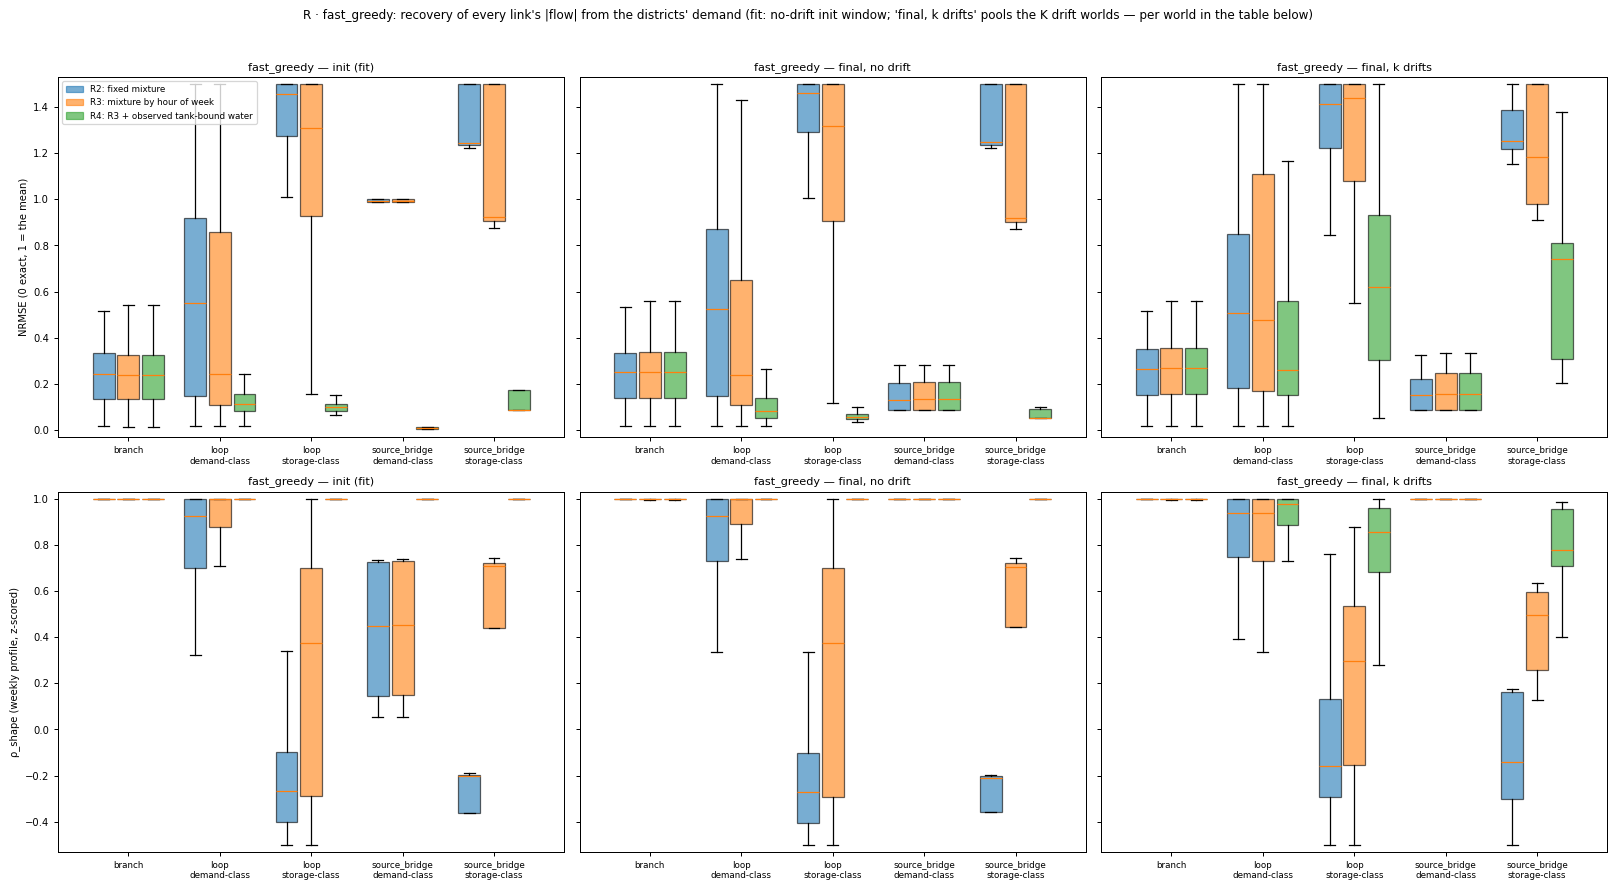

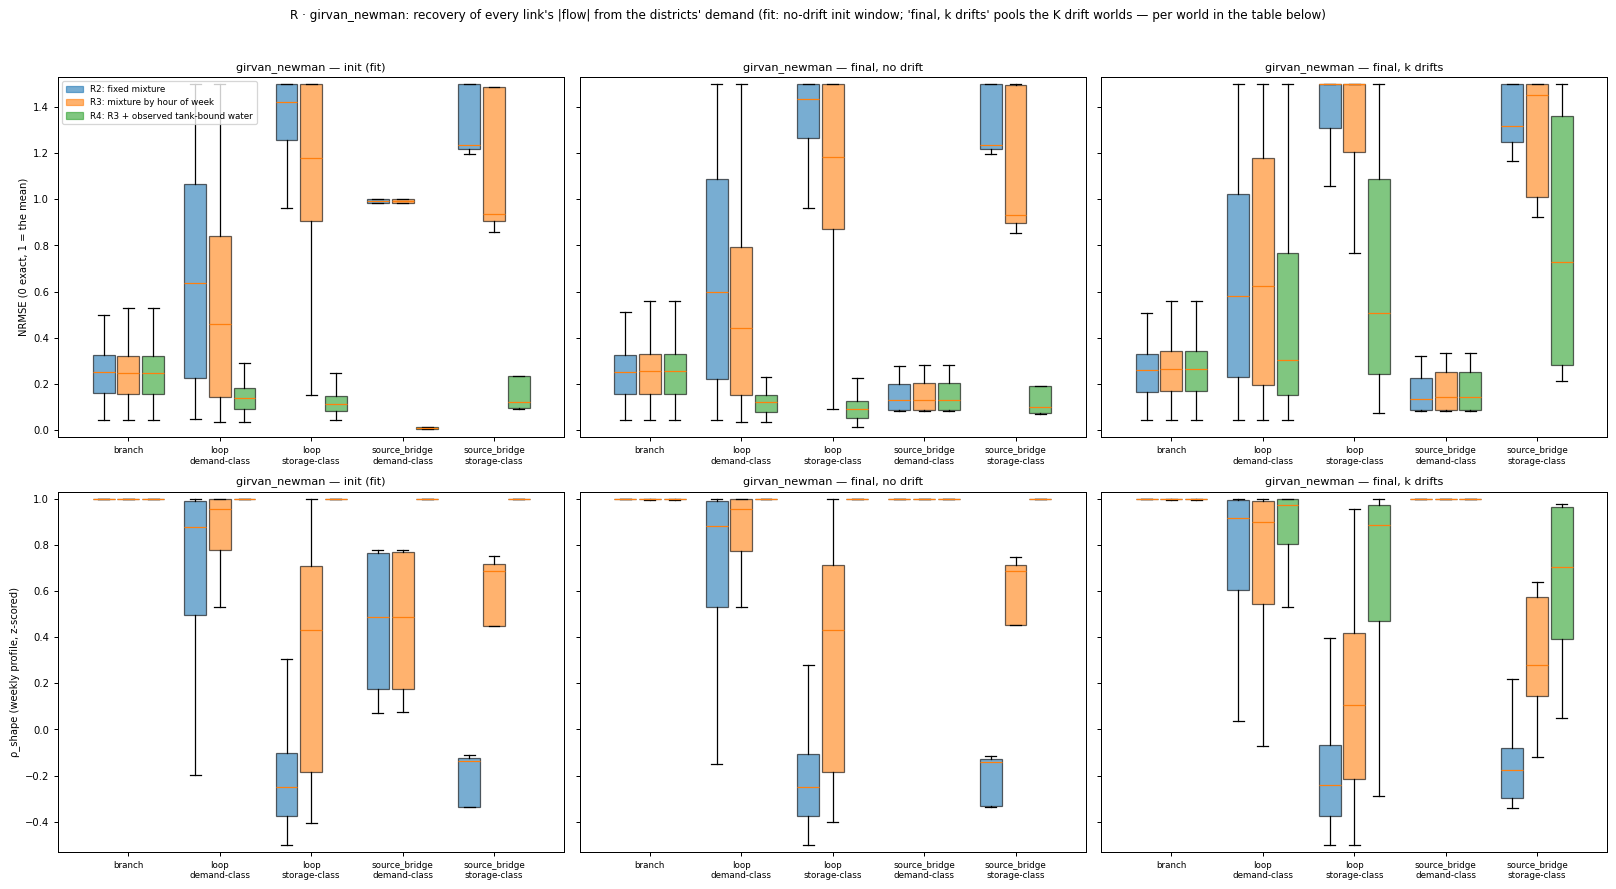

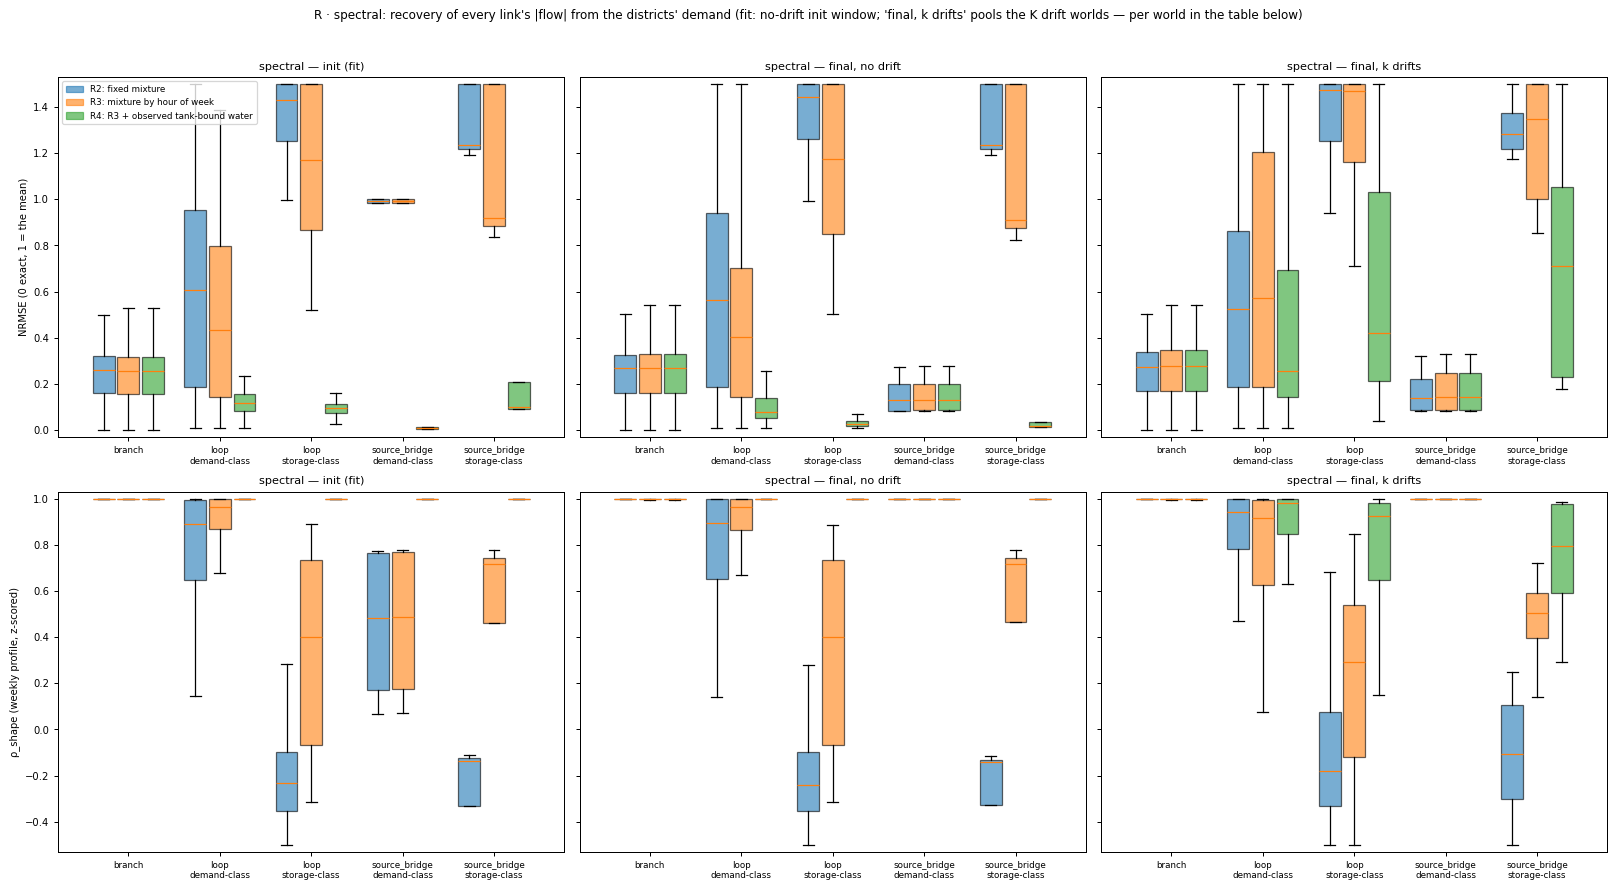

**Per partition, class, window, model** (all links; the drift window pooled over worlds)

links             nrmse_med               nrmse_q90               rho_med               rho_q10              
model                                                          R2    R3    R4        R2     R3     R4        R2     R3     R4      R2     R3     R4      R2     R3     R4
districting   group                         window                                                                                                                       
fast_greedy   branch                        final, k drifts   660   660   660     0.264  0.267  0.267     1.021  0.507  0.507   1.000  0.999  0.999   0.945  0.988  0.988
                                            final, no drift   660   660   660     0.253  0.254  0.254     0.407  0.409  0.409   1.000  0.999  0.999   0.998  0.996  0.996
                                            init (fit)        165   165   165     0.244  0.241  0.241     0.412  0.403  0.403   0.999  1.000  1.000   0.997  1.000  1.000
              loop · demand-class           final, k drifts   404   404   404     0.509  0.478  0.263     1.412  1.537  1.283   0.938  0.938  0.975   0.331  0.403  0.589
                                            final, no drift   404   404   404     0.523  0.241  0.082     1.397  1.369  0.217   0.925  0.997  1.000   0.320  0.572  0.999
                                            init (fit)        101   101   101     0.549  0.243  0.114     1.334  1.316  0.223   0.925  0.998  1.000   0.145  0.586  1.000
              loop · storage-class          final, k drifts  1272  1272  1272     1.410  1.438  0.619     2.148  2.764  1.501  -0.159  0.297  0.857  -0.470 -0.332  0.498
                                            final, no drift  1272  1272  1272     1.462  1.319  0.059     2.099  2.293  0.084  -0.269  0.374  1.000  -0.452 -0.409  1.000
                                            init (fit)        318   318   318     1.456  1.310  0.099     2.073  2.255  0.141  -0.265  0.374  1.000  -0.450 -0.405  1.000
              source_bridge · demand-class  final, k drifts    16    16    16     0.151  0.159  0.159     0.279  0.281  0.281   1.000  0.999  0.999   1.000  0.996  0.996
                                            final, no drift    16    16    16     0.133  0.136  0.136     0.278  0.280  0.280   1.000  1.000  1.000   1.000  0.999  0.999
                                            init (fit)          4     4     4     0.995  0.995  0.010     1.001  1.001  0.014   0.448  0.452  1.000   0.090  0.093  1.000
              source_bridge · storage-class final, k drifts    48    48    48     1.252  1.184  0.740     1.695  1.703  1.369  -0.142  0.495  0.778  -0.533  0.131  0.403
                                            final, no drift    48    48    48     1.246  0.920  0.055     1.638  1.574  0.096  -0.210  0.704  1.000  -0.357  0.443  1.000
                                            init (fit)         12    12    12     1.246  0.925  0.089     1.617  1.557  0.175  -0.203  0.706  1.000  -0.361  0.441  1.000
girvan_newman branch                        final, k drifts   660   660   660     0.261  0.265  0.265     0.438  0.447  0.447   1.000  0.999  0.999   0.998  0.990  0.990
                                            final, no drift   660   660   660     0.253  0.257  0.257     0.382  0.385  0.385   1.000  0.999  0.999   0.999  0.997  0.997
                                            init (fit)        165   165   165     0.253  0.249  0.249     0.375  0.369  0.369   0.999  1.000  1.000   0.997  1.000  1.000
              loop · demand-class           final, k drifts   472   472   472     0.583  0.623  0.304     1.425  1.599  1.532   0.914  0.897  0.970   0.009  0.238  0.440
                                            final, no drift   472   472   472     0.599  0.443  0.121     1.401  1.232  0.219   0.882  0.953  1.000  -0.116  0.542  0.999
                                            init (fit)        118   118   118     0.638  0.458  0.138     1.369  1.202  0.228   0.876  0.956  1.000  -

**Per drift world** (final window, k drifts; median NRMSE)

model                                                      R2     R3     R4
districting   k          group                                             
fast_greedy   District_A branch                         0.266  0.269  0.269
                         loop · demand-class            0.492  0.438  0.318
                         loop · storage-class           1.448  1.408  0.847
                         source_bridge · demand-class   0.133  0.136  0.136
                         source_bridge · storage-class  1.269  1.205  0.809
              District_B branch                         0.277  0.278  0.278
                         loop · demand-class            0.458  0.626  0.563
                         loop · storage-class           1.425  1.970  1.212
                         source_bridge · demand-class   0.164  0.185  0.185
                         source_bridge · storage-class  1.253  1.185  0.811
              District_C branch                         0.275  0.277  0.277
                         loop · demand-class            0.525  0.423  0.254
                         loop · storage-class           1.400  1.297  0.373
                         source_bridge · demand-class   0.134  0.136  0.136
                         source_bridge · storage-class  1.173  0.946  0.318
              District_D branch                         0.251  0.254  0.254
                         loop · demand-class            0.554  0.516  0.200
                         loop · storage-class           1.386  1.246  0.286
                         source_bridge · demand-class   0.134  0.136  0.136
                         source_bridge · storage-class  1.223  0.988  0.216
girvan_newman District_A branch                         0.269  0.272  0.272
                         loop · demand-class            0.585  0.896  0.694
                         loop · storage-class           1.575  1.686  1.218
                         source_bridge · demand-class   0.130  0.132  0.132
                         source_bridge · storage-class  1.528  1.780  1.410
              District_B branch                         0.270  0.272  0.272
                         loop · demand-class            0.553  0.804  0.728
                         loop · storage-class           1.479  1.725  1.055
                         source_bridge · demand-class   0.155  0.175  0.175
                         source_bridge · storage-class  1.294  1.399  0.991
              District_C branch                         0.264  0.268  0.268
                         loop · demand-class            0.590  0.513  0.295
                         loop · storage-class           1.344  1.126  0.292
                         source_bridge · demand-class   0.130  0.133  0.133
                         source_bridge · storage-class  1.188  0.966  0.289
              District_D branch                         0.254  0.256  0.256
                         loop · demand-class            0.620  0.506  0.160
                         loop · storage-class           1.527  1.417  0.225
                         source_bridge · demand-class   0.131  0.133  0.133
                         source_bridge · storage-class  1.255  1.021  0.219
spectral      District_A branch                         0.302  0.313  0.313
                         loop · demand-class            0.506  0.908  0.672
                         loop · storage-class           1.580  1.669  0.972
                         source_bridge · demand-class   0.129  0.132  0.132
                         source_bridge · storage-class  1.373  1.401  1.121
              District_B branch                         0.282  0.284  0.284
                         loop · demand-class            0.505  0.669  0.564
                         loop · storage-class           1.514  1.688  1.074
                         source_bridge · demand-class   0.155  0.176  0.176
                         source_bridge · storage-class  1.299  1.340  1.029
              District_C branch                 

**Placed sensors** (median NRMSE / ρ_shape)

sensors         nrmse_med               rho_med              
model                                                   R2  R3  R4        R2     R3     R4      R2     R3     R4
districting   group                window                                                                       
fast_greedy   branch               final, k drifts      20  20  20     0.119  0.114  0.114   1.000  1.000  1.000
                                   final, no drift      20  20  20     0.129  0.119  0.119   1.000  1.000  1.000
                                   init (fit)            5   5   5     0.124  0.107  0.107   1.000  1.000  1.000
              loop · demand-class  final, k drifts      16  16  16     0.112  0.115  0.115   1.000  1.000  1.000
                                   final, no drift      16  16  16     0.109  0.111  0.111   1.000  1.000  1.000
                                   init (fit)            4   4   4     0.105  0.102  0.102   1.000  1.000  1.000
              loop · storage-class final, k drifts      28  28  28     1.625  1.625  0.850  -0.350  0.106  0.696
                                   final, no drift      28  28  28     1.806  1.791  0.083  -0.428  0.149  1.000
                                   init (fit)            7   7   7     1.784  1.776  0.142  -0.425  0.151  1.000
girvan_newman branch               final, k drifts      12  12  12     0.065  0.066  0.066   1.000  1.000  1.000
                                   final, no drift      12  12  12     0.065  0.065  0.065   1.000  1.000  1.000
                                   init (fit)            3   3   3     0.055  0.054  0.054   1.000  1.000  1.000
              loop · demand-class  final, k drifts      28  28  28     0.121  0.123  0.123   1.000  1.000  1.000
                                   final, no drift      28  28  28     0.105  0.106  0.101   1.000  1.000  1.000
                                   init (fit)            7   7   7     0.095  0.093  0.093   1.000  1.000  1.000
              loop · storage-class final, k drifts      24  24  24     1.406  1.499  0.824  -0.088  0.287  0.706
                                   final, no drift      24  24  24     1.369  1.078  0.150  -0.087  0.545  0.999
                                   init (fit)            6   6   6     1.341  1.091  0.184  -0.085  0.542  1.000
spectral      branch               final, k drifts      16  16  16     0.045  0.046  0.046   1.000  1.000  1.000
                                   final, no drift      16  16  16     0.045  0.046  0.046   1.000  1.000  1.000
                                   init (fit)            4   4   4     0.044  0.044  0.044   1.000  1.000  1.000
              loop · demand-class  final, k drifts      24  24  24     0.071  0.073  0.073   1.000  1.000  1.000
                                   final, no drift      24  24  24     0.068  0.069  0.069   1.000  1.000  1.000
                                   init (fit)            6   6   6     0.068  0.067  0.067   1.000  1.000  1.000
              loop · storage-class final, k drifts      24  24  24     1.494  1.287  0.478  -0.274  0.283  0.872
                                   final, no drift      24  24  24     1.517  1.191  0.038  -0.312  0.406  1.000
                                   init (fit)            6   6   6     1.509  1.189  0.109  -0.310  0.405  1.000

In [6]:
# R · how well a mixture of the districts' demand recovers each link's |flow|, per class and window
if not GATES_OK:
    display(Markdown("**R skipped** (a gate failed)."))
else:
    for m in PARTS:
        q = RECT[(RECT["districting"] == m) & RECT["group"].isin(GRP)]
        fig, axes = plt.subplots(2, 3, figsize=(18, 10), squeeze=False, sharey="row")
        for i, (met, lim, lab) in enumerate((("nrmse", (0, 1.5), "NRMSE (0 exact, 1 = the mean)"),
                                             ("rho_shape", (-0.5, 1.0), "ρ_shape (weekly profile, z-scored)"))):
            for j, w in enumerate(WIN):
                ax = axes[i, j]
                for mi, (mod, col, _) in enumerate(MODS):
                    data = [q[(q["window"] == w) & (q["model"] == mod) & (q["group"] == gg)][met].dropna().clip(*lim)
                            for gg in GRP]
                    bp = ax.boxplot(data, positions=np.arange(len(GRP)) + (mi - 1) * 0.27, widths=0.24,
                                    showfliers=False, patch_artist=True)
                    for b in bp["boxes"]:
                        b.set(facecolor=col, alpha=0.6)
                ax.set_xticks(range(len(GRP)), [gg.replace(" · ", "\n") for gg in GRP], fontsize=7)
                ax.set_ylim(lim[0] - 0.03, lim[1] + 0.03)
                ax.set_title(f"{m} — {w}", fontsize=9)
                if j == 0:
                    ax.set_ylabel(lab)
        axes[0, 0].legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.6, label=f"{mod}: {t}") for mod, c, t in MODS],
                          fontsize=7, loc="upper left")
        fig.suptitle(f"R · {m}: recovery of every link's |flow| from the districts' demand (fit: no-drift init window; "
                     "'final, k drifts' pools the K drift worlds — per world in the table below)")
        fig.tight_layout(rect=(0, 0, 1, 0.96)); plt.show()

    agg = dict(links=("nrmse", "size"), nrmse_med=("nrmse", "median"), nrmse_q90=("nrmse", lambda x: x.quantile(0.9)),
               rho_med=("rho_shape", "median"), rho_q10=("rho_shape", lambda x: x.quantile(0.1)))
    display(Markdown("**Per partition, class, window, model** (all links; the drift window pooled over worlds)"))
    display(RECT[RECT["group"].isin(GRP) & (RECT["model"] != "R1")].groupby(
        ["districting", "group", "window", "model"]).agg(**agg).round(3).unstack("model"))
    display(Markdown("**Per drift world** (final window, k drifts; median NRMSE)"))
    display(RECT[RECT["group"].isin(GRP) & (RECT["window"] == "final, k drifts") & (RECT["model"] != "R1")].pivot_table(
        index=["districting", "k", "group"], columns="model", values="nrmse", aggfunc="median").round(3))
    display(Markdown("**Placed sensors** (median NRMSE / ρ_shape)"))
    display(RECT[RECT["placed"] & (RECT["model"] != "R1")].groupby(["districting", "group", "window", "model"]).agg(
        sensors=("nrmse", "size"), nrmse_med=("nrmse", "median"), rho_med=("rho_shape", "median")).round(3).unstack("model"))

### R · gallery and widget

One week of the link's |flow| with its three recoveries (left) and where that water goes, hour by hour (right).
Gallery: best / median / worst link per class by R3, out of the fitting window. Widget: any partition, window (init,
final no drift, final drift — per world), class, link, saved week (first / last of the window).

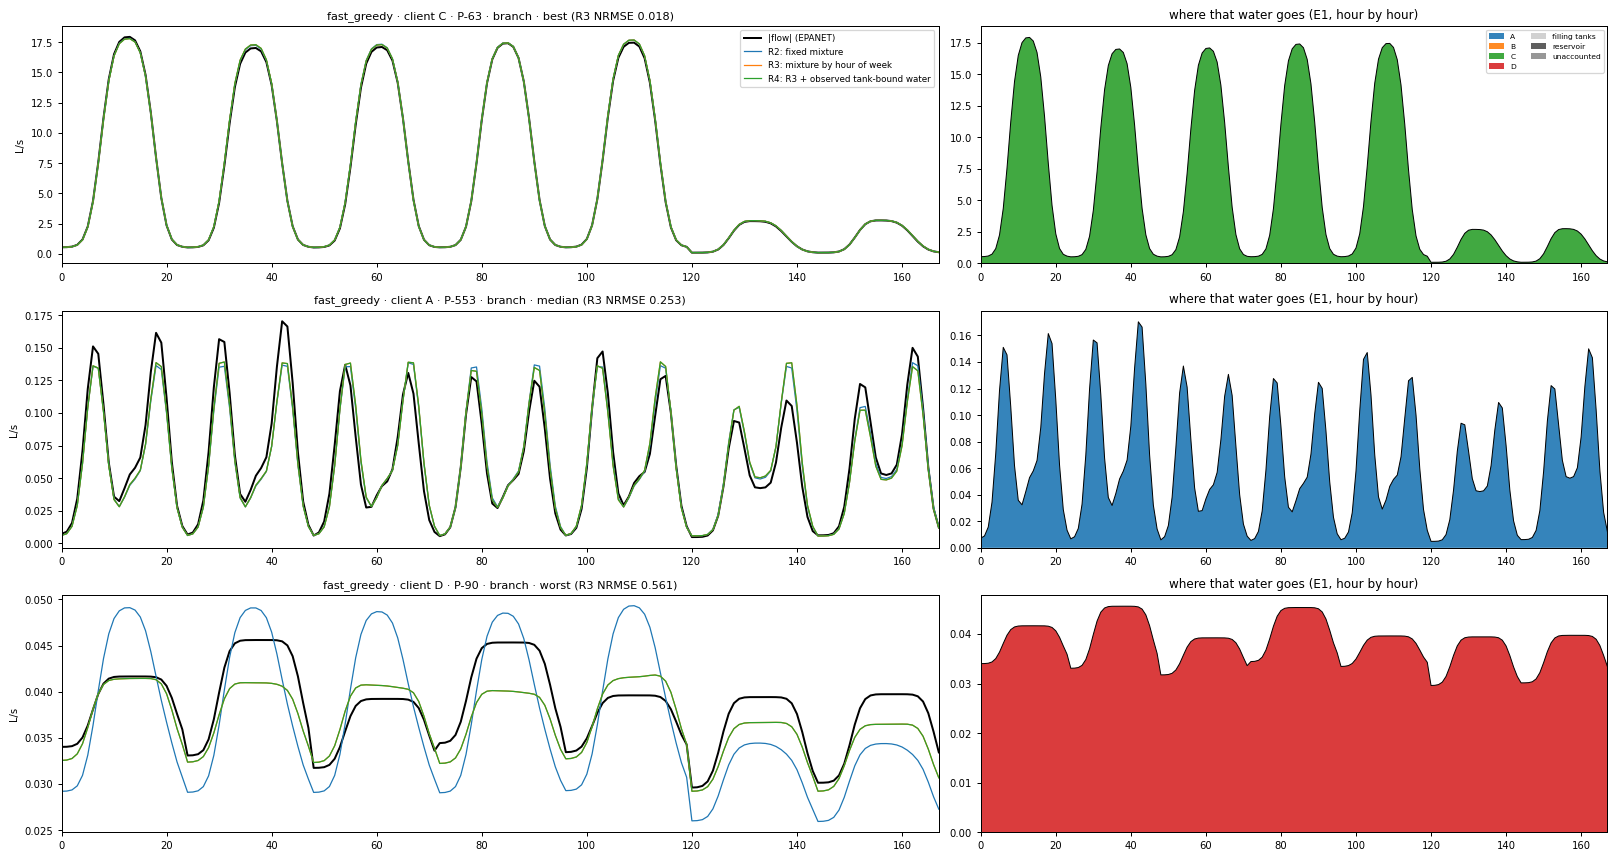

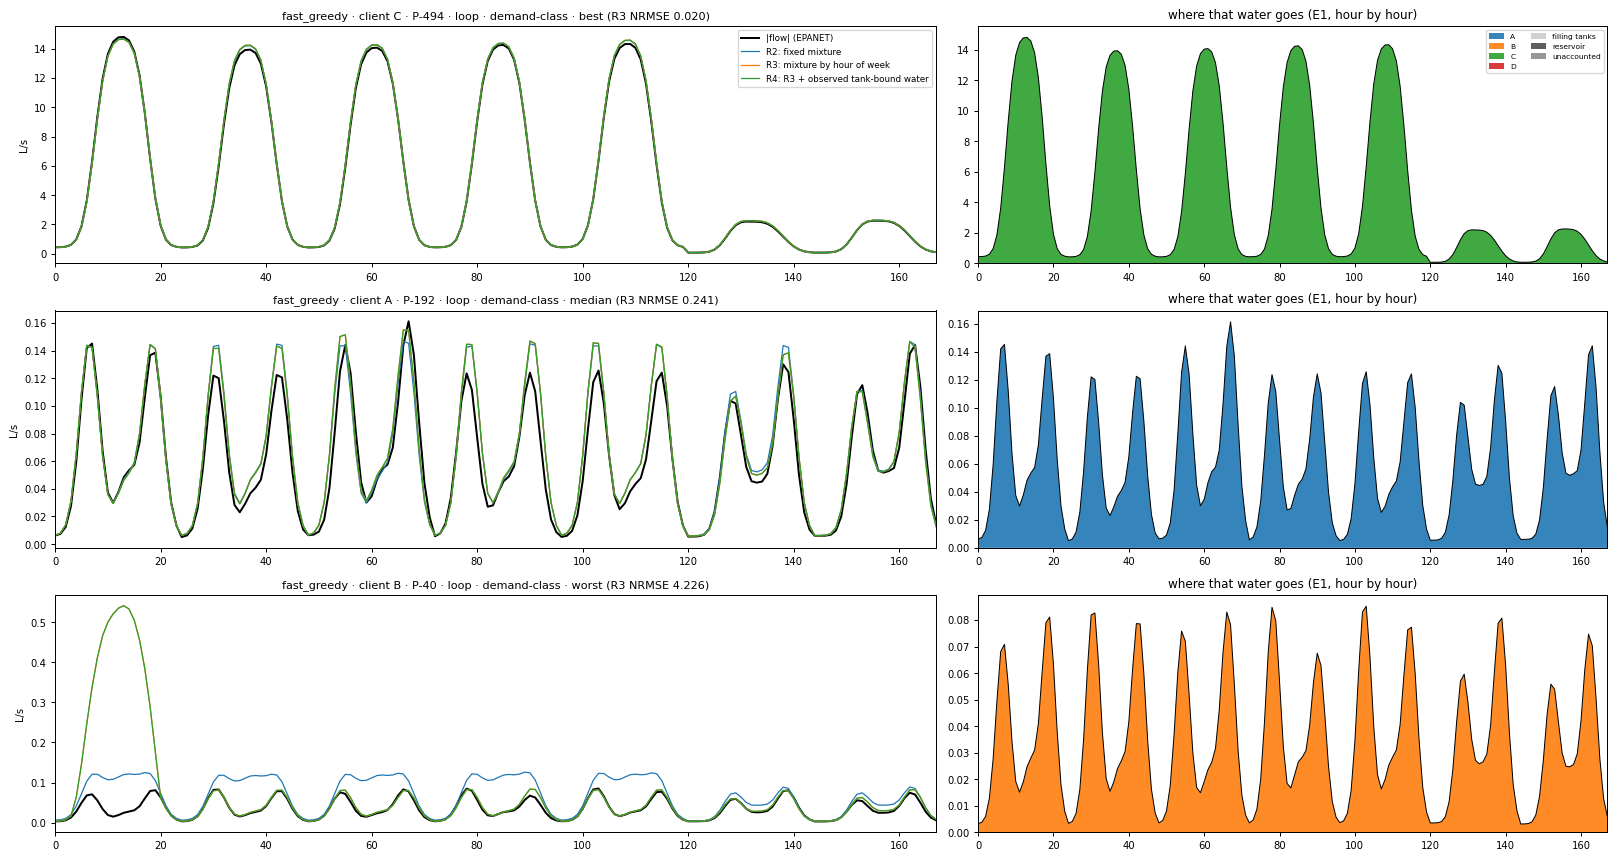

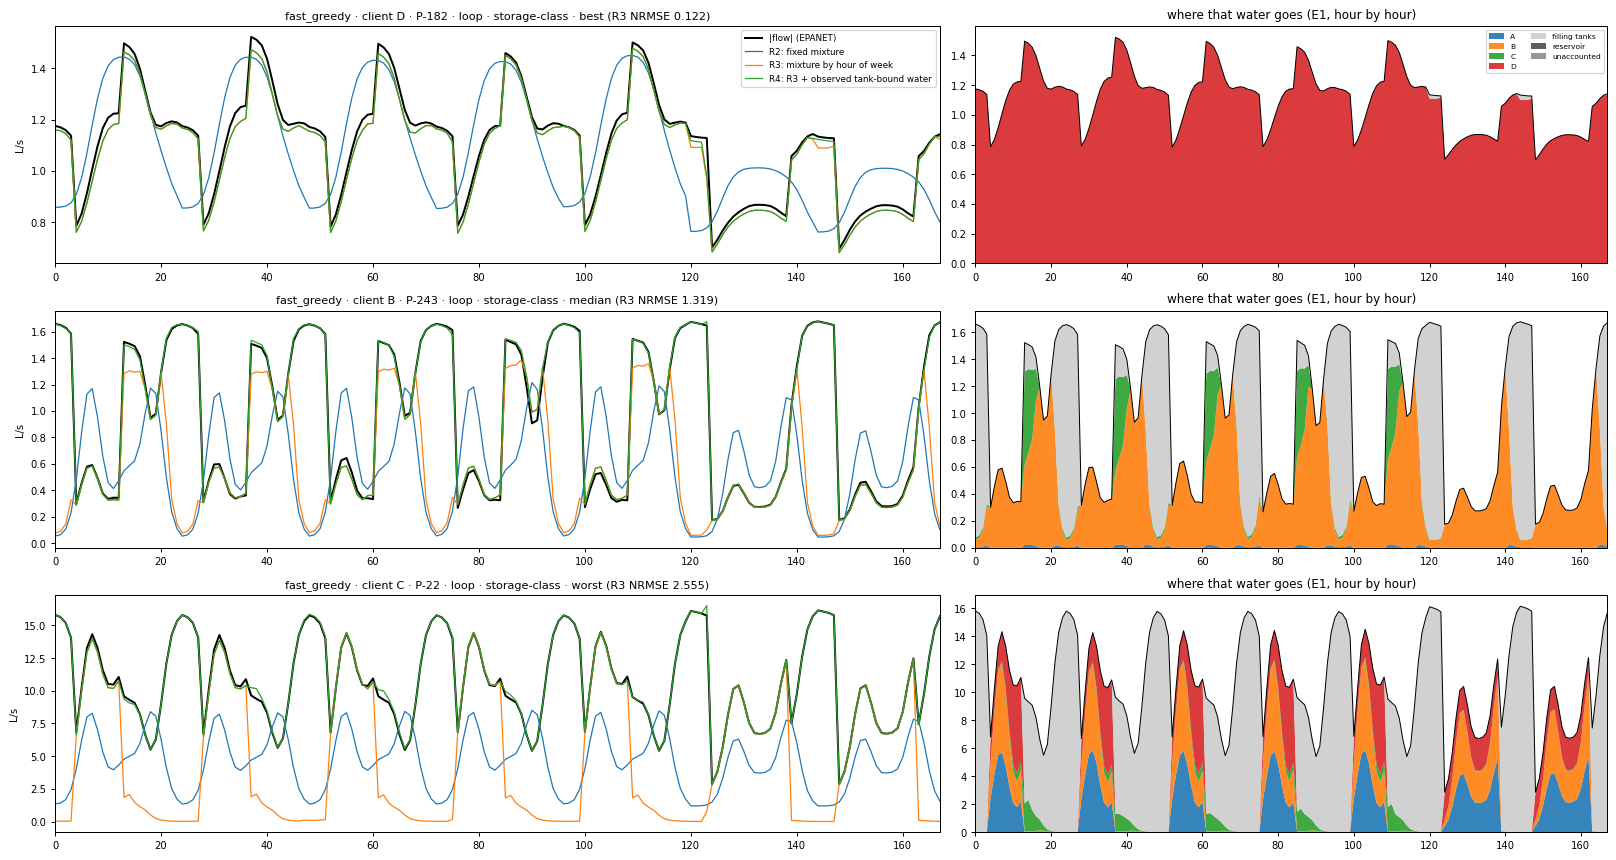

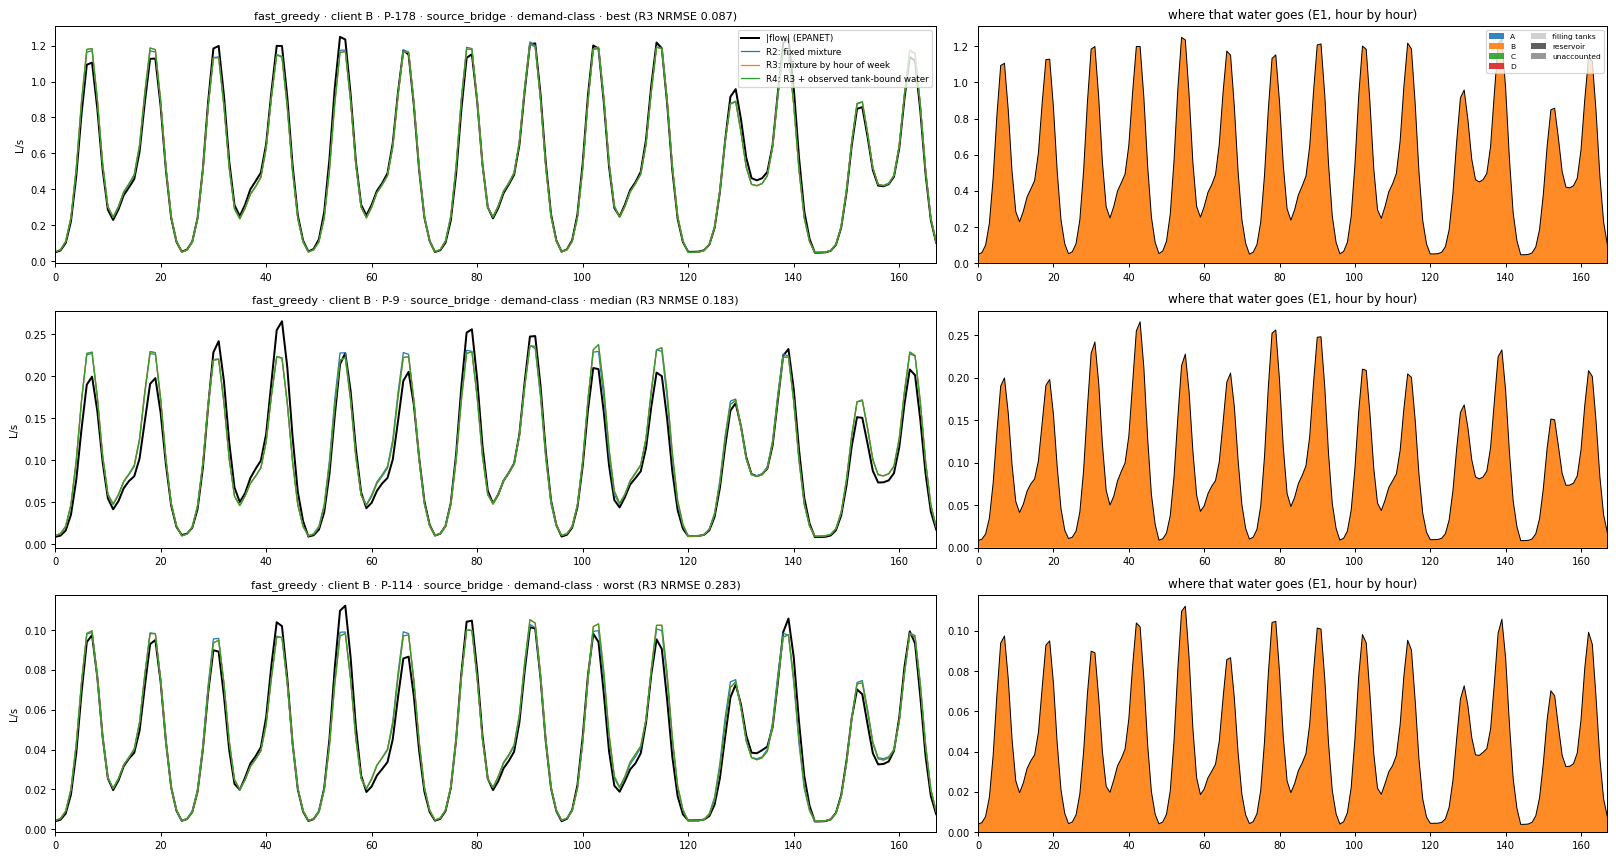

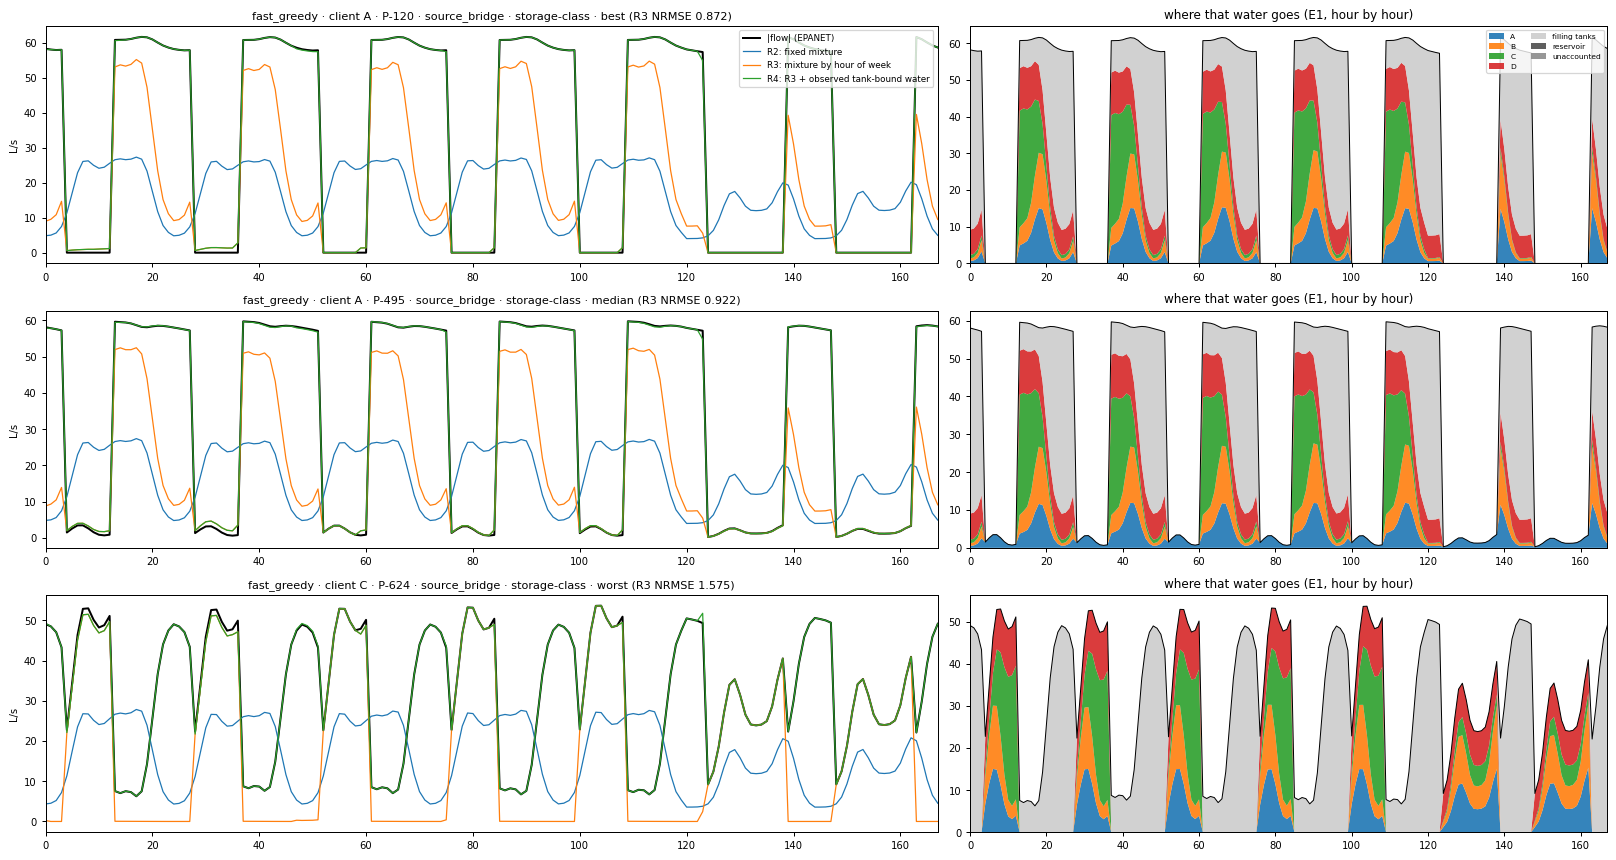

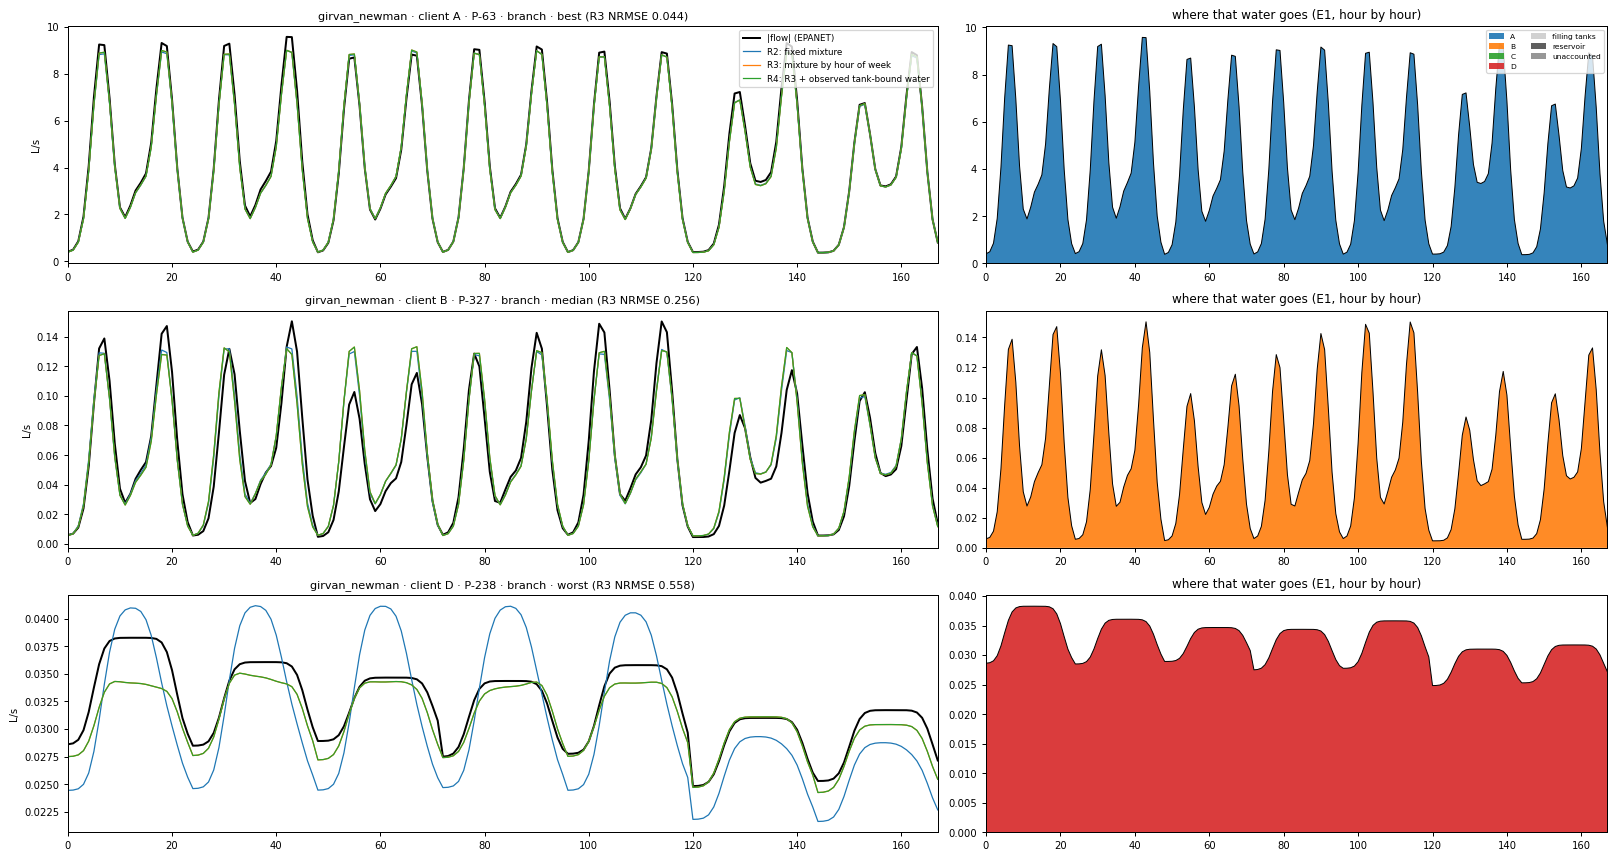

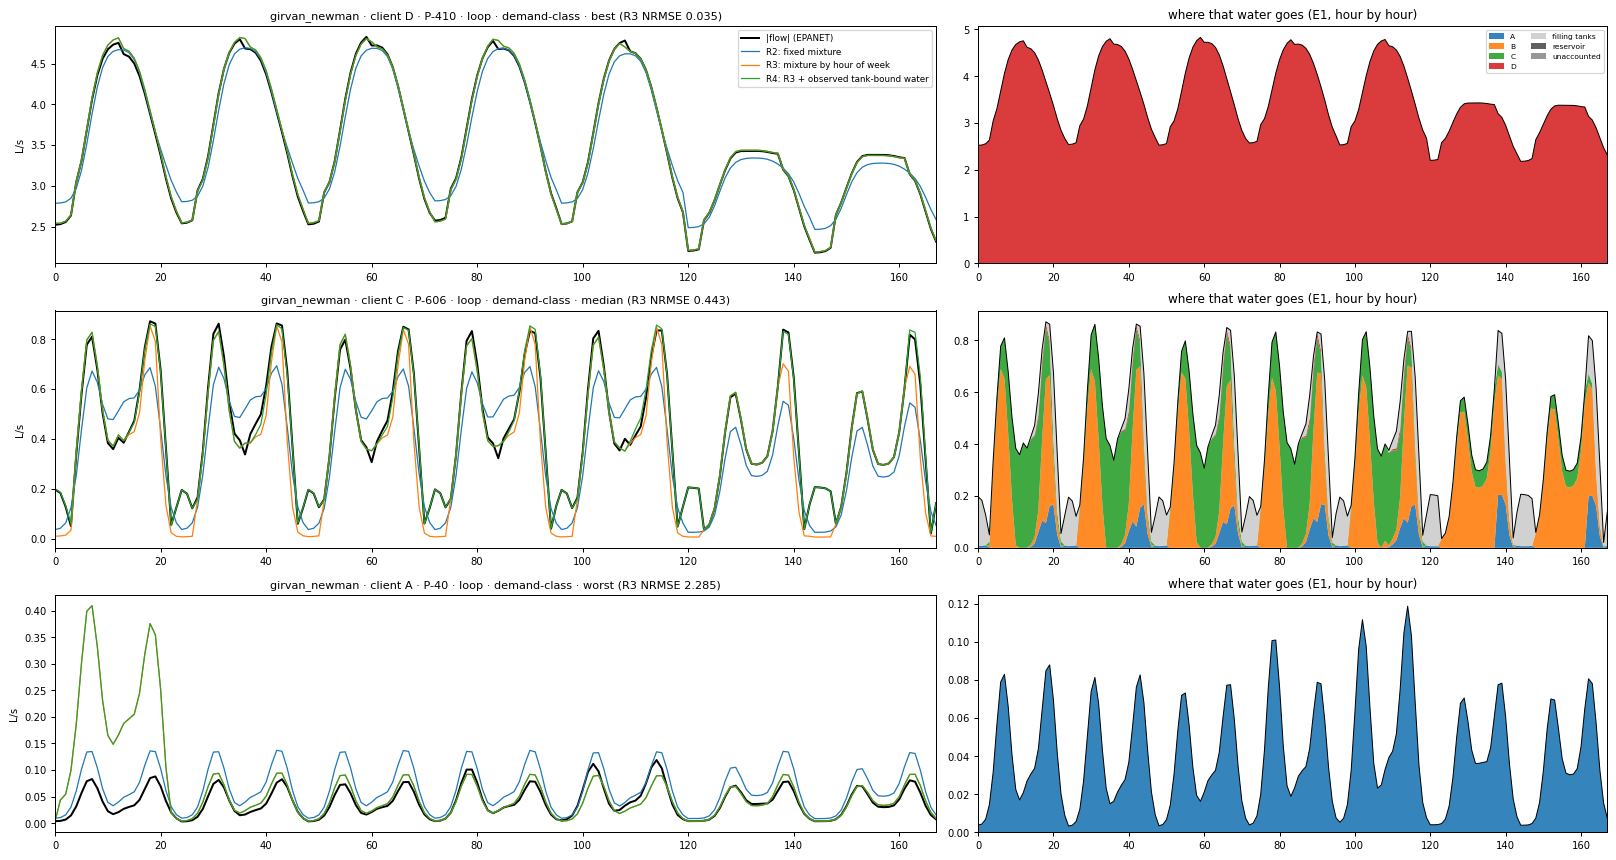

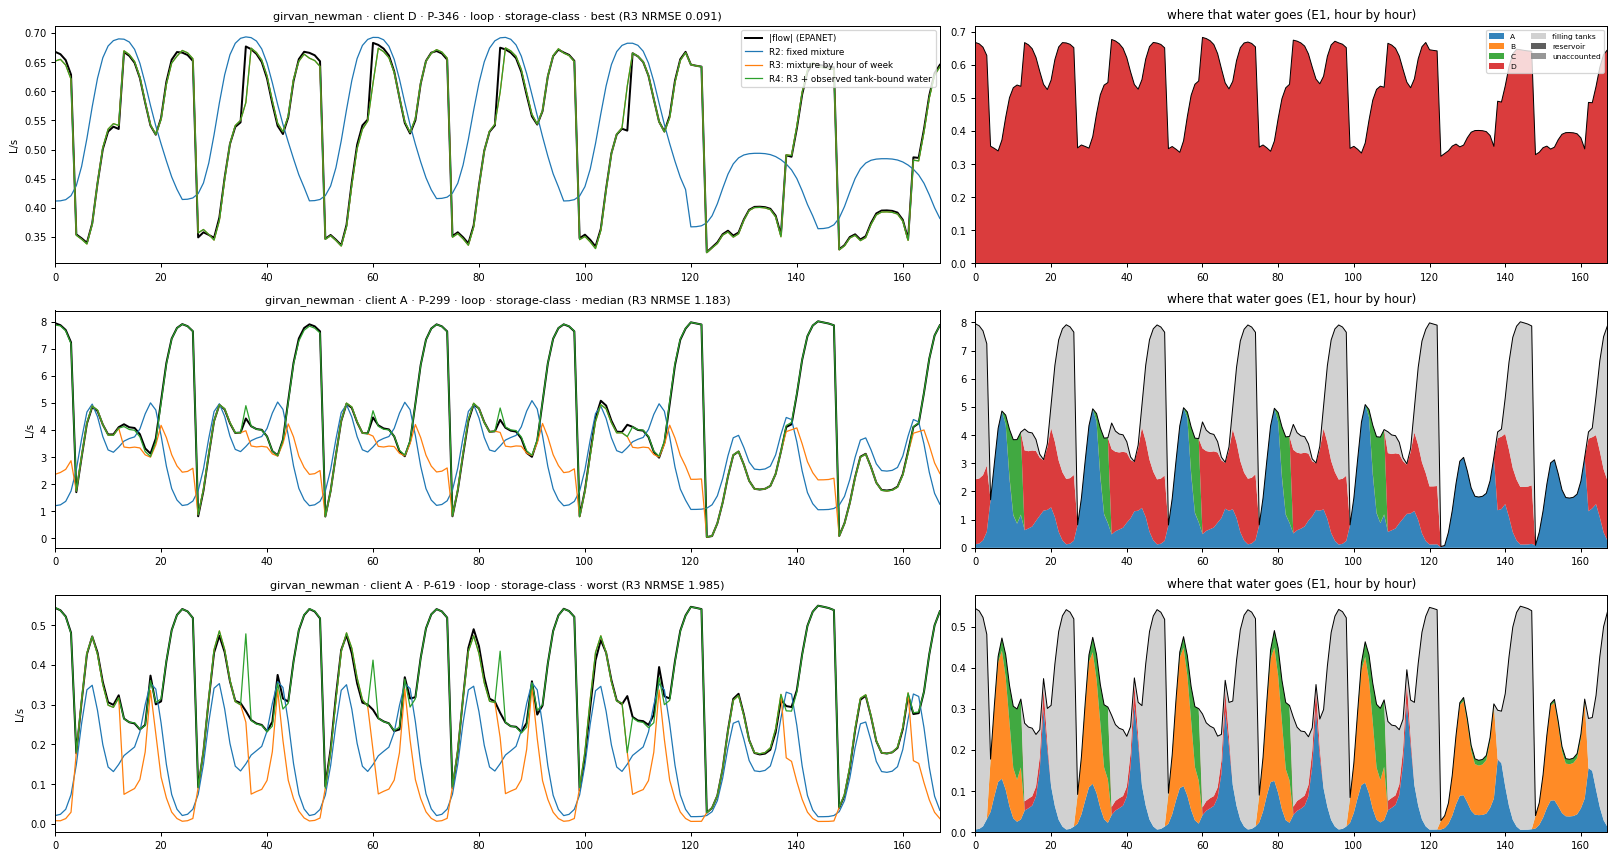

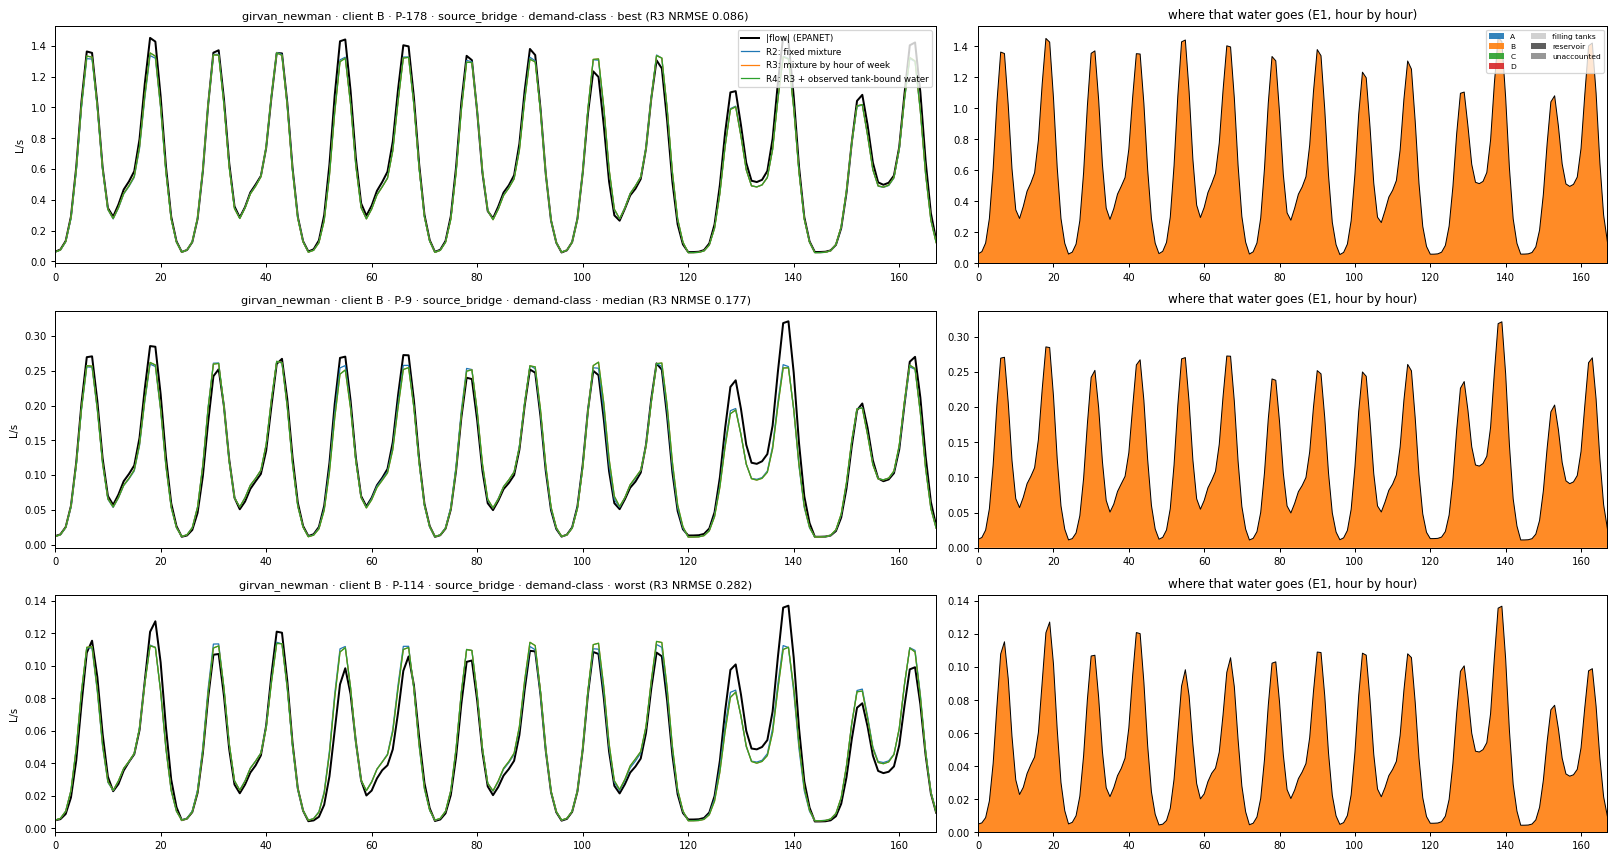

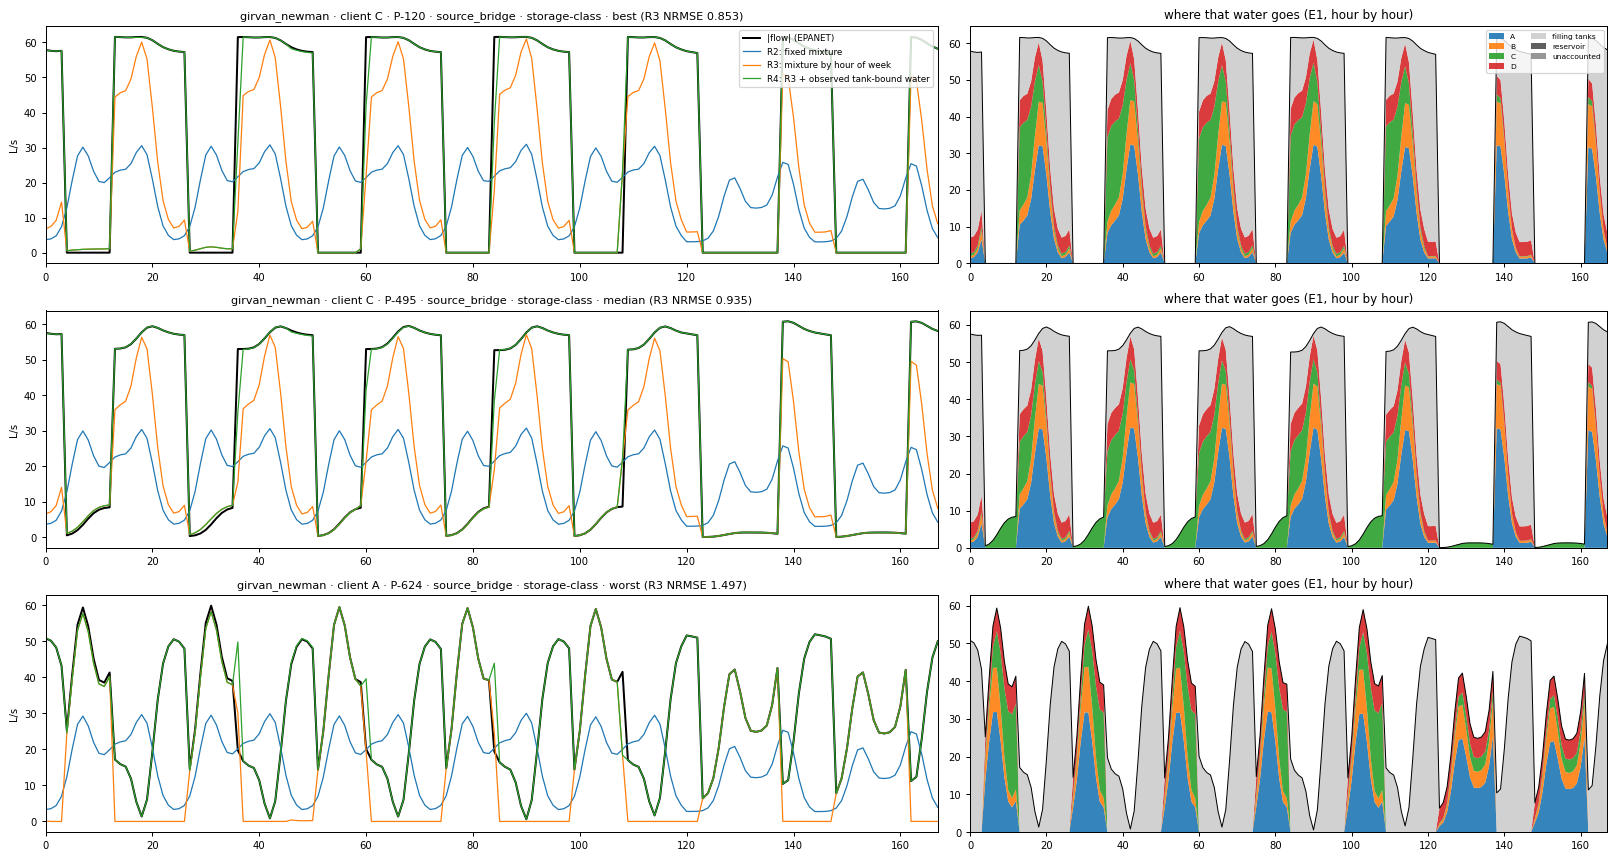

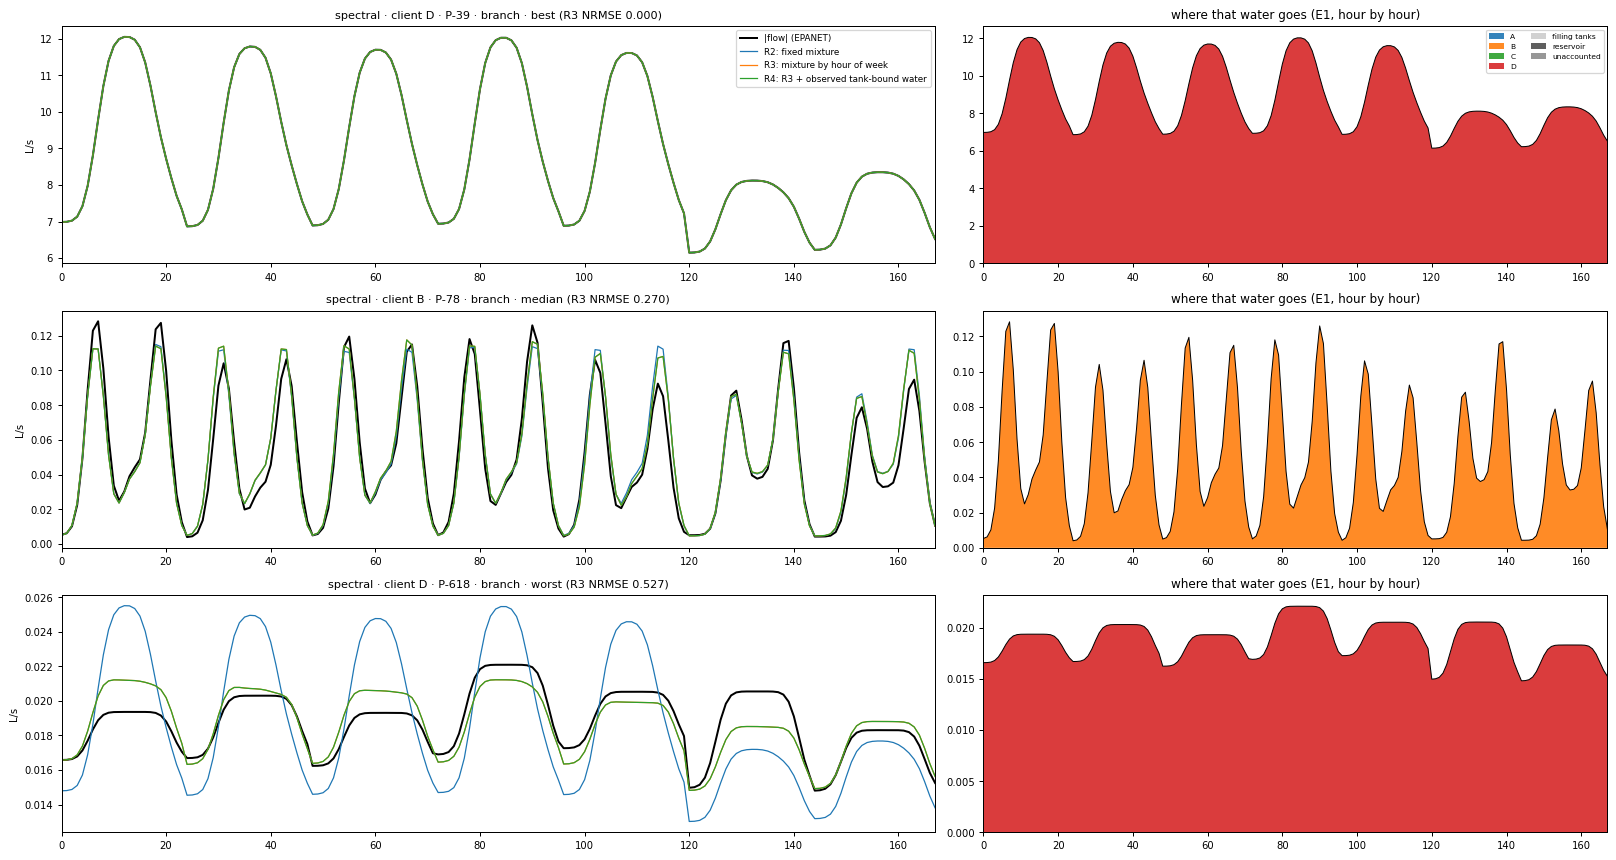

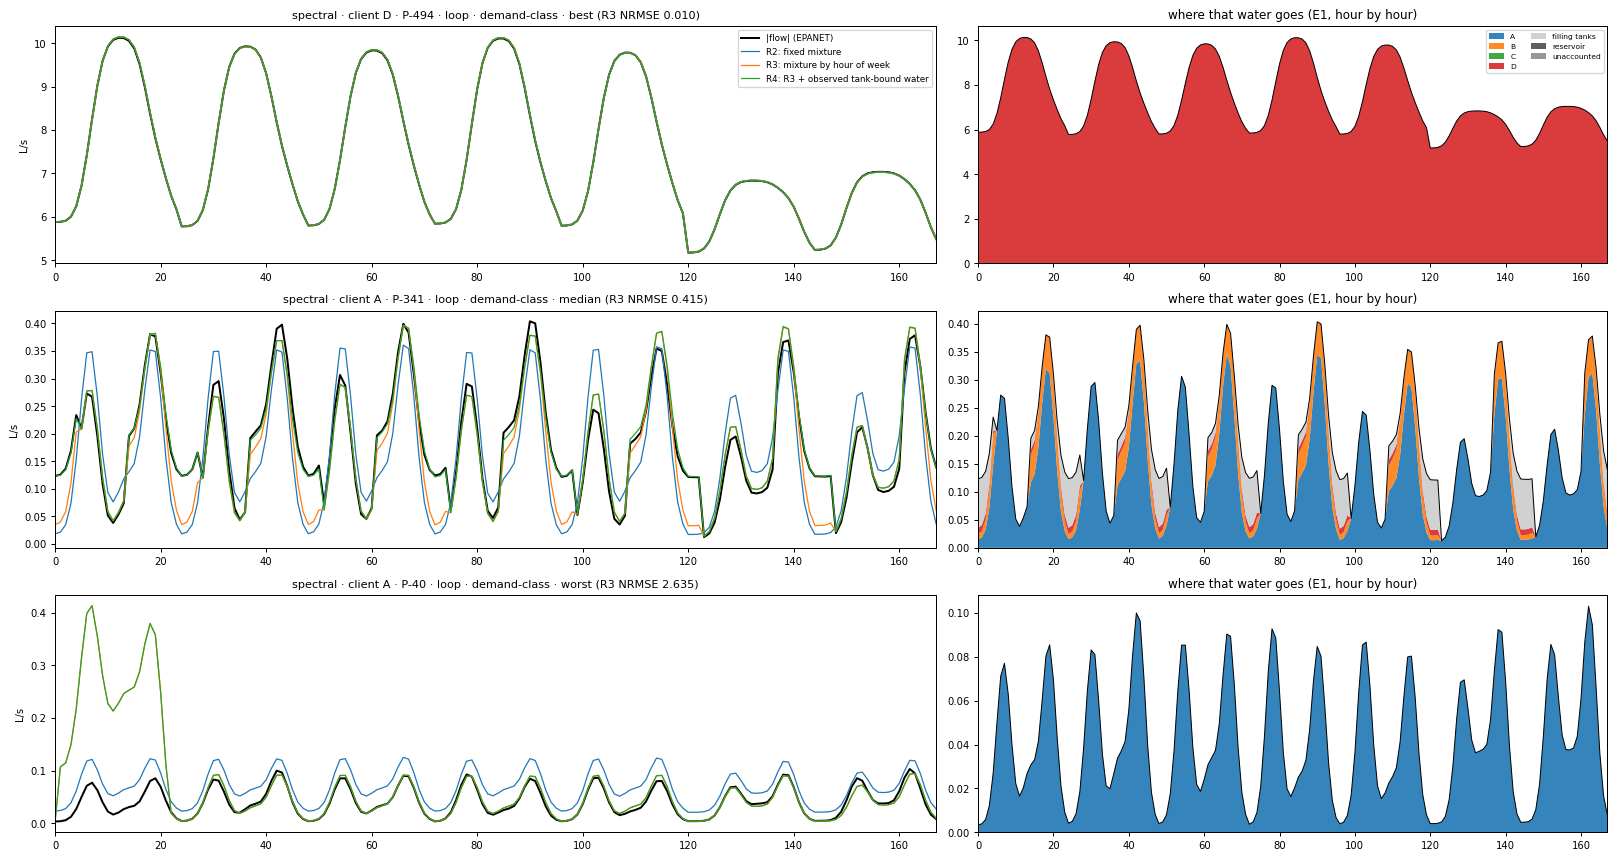

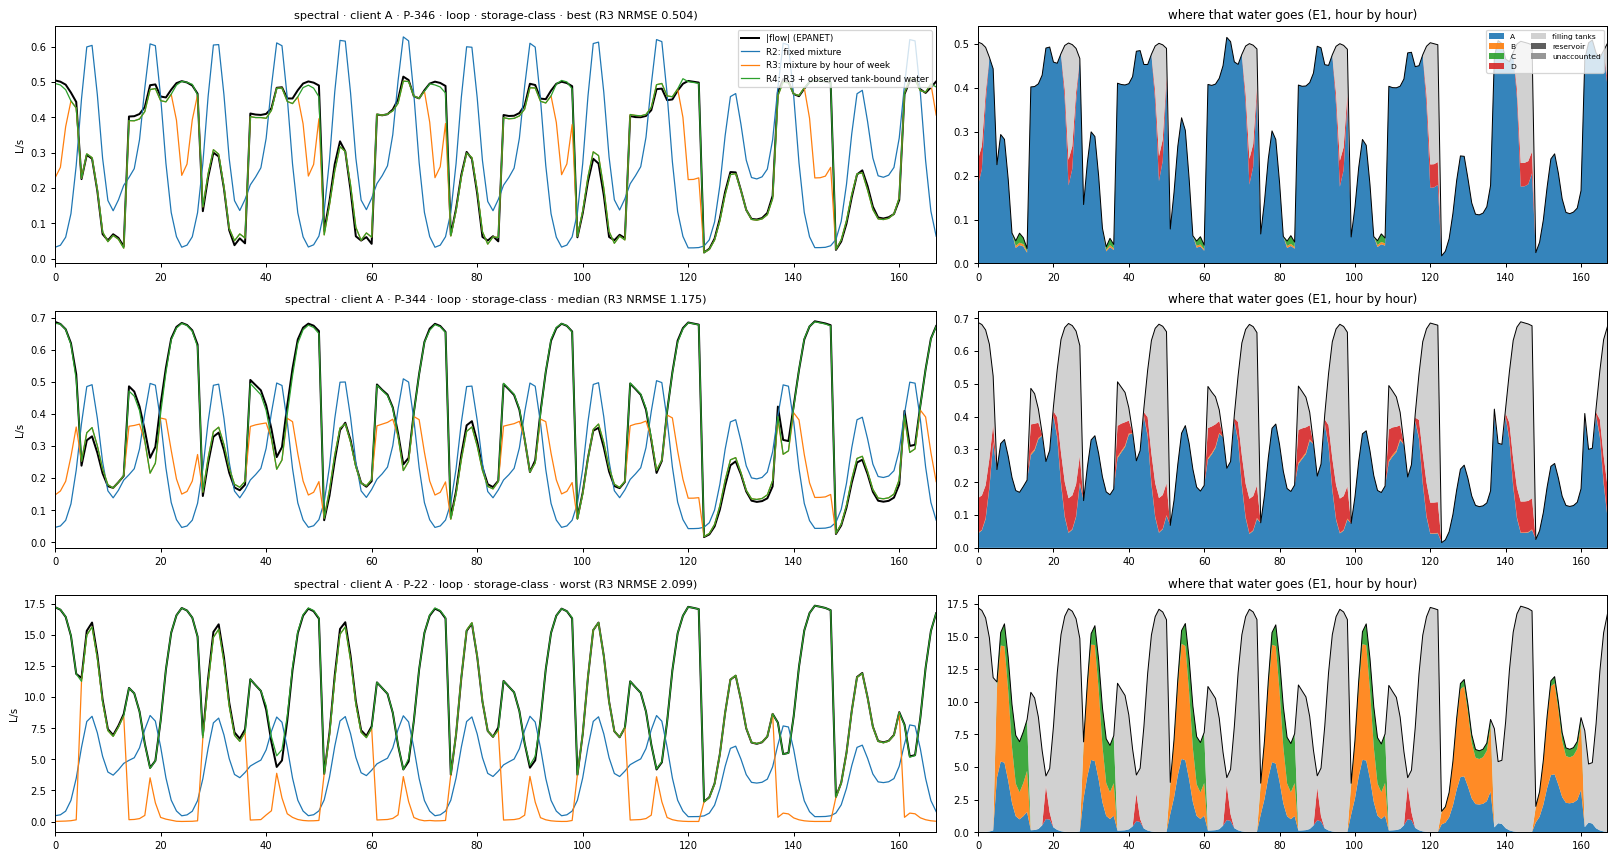

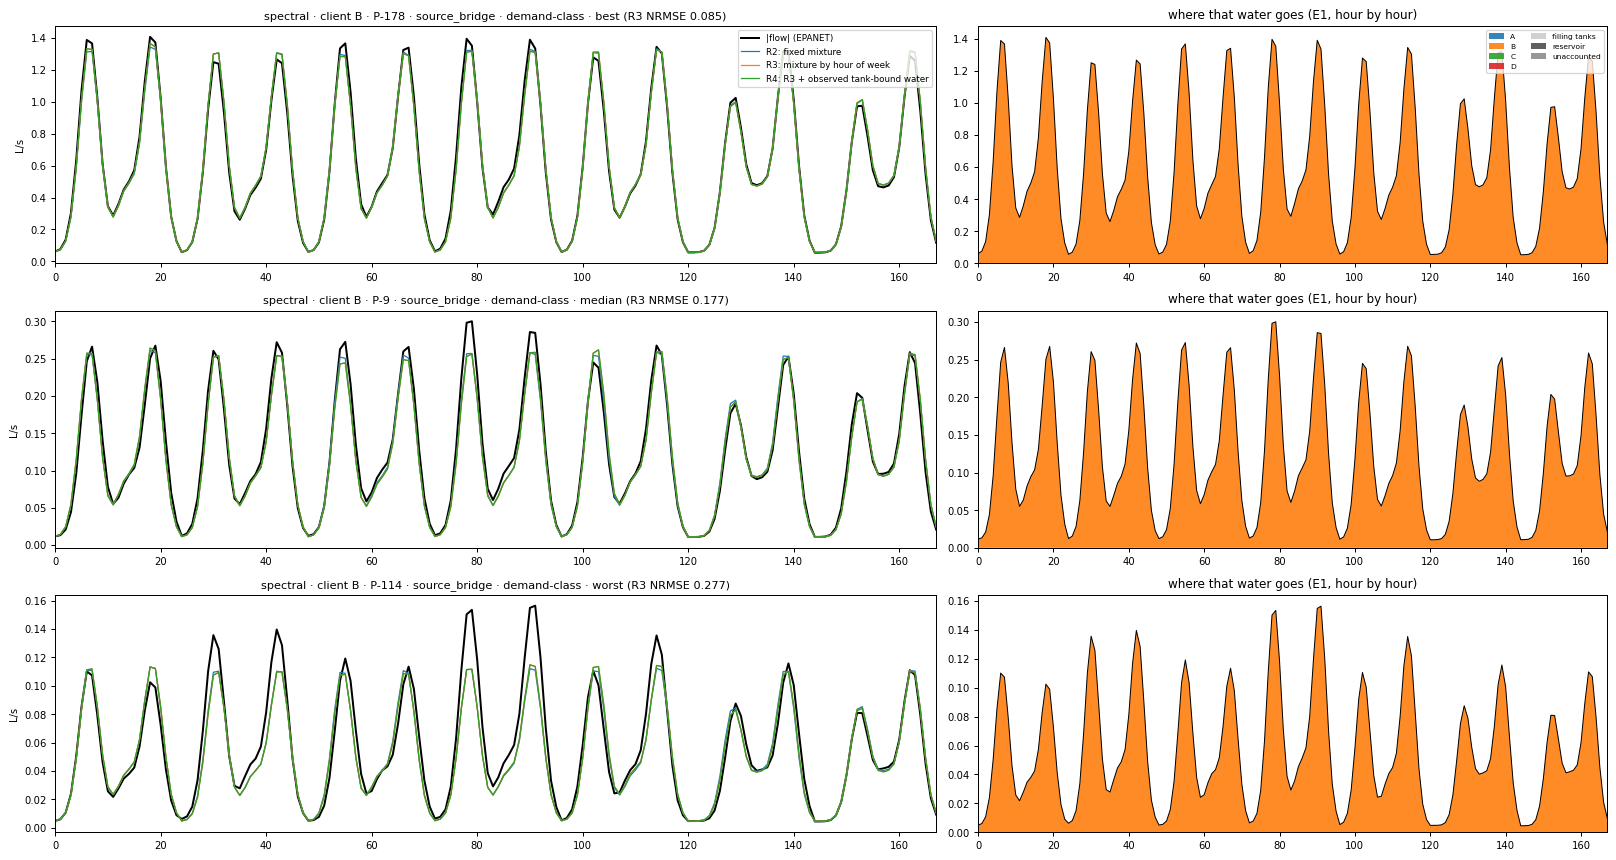

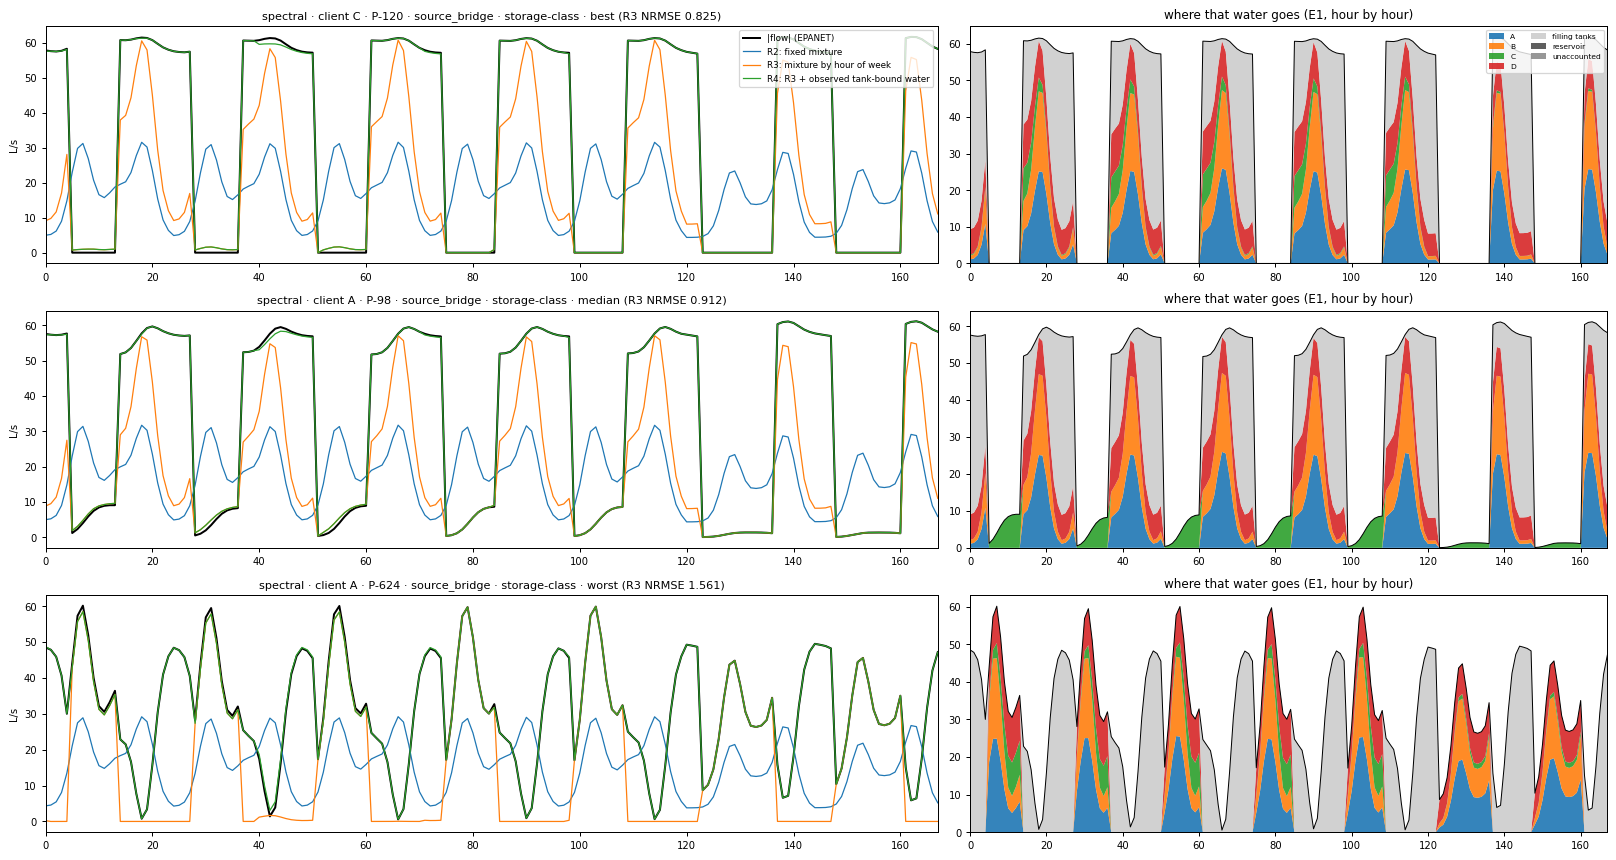

In [7]:
# R · gallery: per class, the links best / median / worst recovered by R3 out of the fitting window (no-drift city,
#     final window of the first drifting district's world), first saved week of that window
_WKS = {}


def wk(m):
    if m not in _WKS:
        z = np.load(OUT / f"weeks__{m}.npz")
        _WKS[m] = {x: z[x] for x in z.files}
    return _WKS[m]


def week(m, tag, i=0):
    z = wk(m)
    starts = sorted({int(x.split("__")[1]) for x in z if x.startswith(tag + "__")})
    if not starts:
        return None, None
    w0 = starts[min(i, len(starts) - 1)]
    return w0, {x: z[f"{tag}__{w0}__{x}"] for x in ("y", "R2", "R3", "R4", "parts", "Dd")}


def week_panel(axl, axr, m, tag, el, i=0):
    """Left: the link's |flow| and its three recoveries over one week. Right: the |flow| split by destination."""
    w0, d = week(m, tag, i)
    z = wk(m)
    cols, names = [str(c) for c in z["cols"]], [str(c) for c in z["names"]]
    if d is None or el not in cols:
        axl.axis("off"); axr.axis("off"); return
    j = cols.index(el)
    t = np.arange(len(d["y"]))
    axl.plot(t, d["y"][:, j], color="k", lw=1.6, label="|flow| (EPANET)")
    for mod, col, txt in MODS:
        axl.plot(t, d[mod][:, j], color=col, lw=1.0, label=f"{mod}: {txt}")
    # axl.set(xlim=(0, len(t) - 1), ylabel="L/s", title=f"{m} · {el} · {tag} · week from hour {w0}")
    h_ = INFO[(INFO["districting"] == m) & (INFO["element"] == el)]["home"]
    h_ = str(h_.iloc[0]).replace("District_", "") if len(h_) else "?"
    axl.set(xlim=(0, len(t) - 1), ylabel="L/s", title=f"{m} · client {h_} · {el} · {tag} · week from hour {w0}")

    dcol = {n: plt.get_cmap("tab10")(i_) for i_, n in enumerate(sorted(names))}
    labs = [n.replace("District_", "") for n in names] + ["filling tanks", "reservoir", "unaccounted"]
    cs = [dcol[n] for n in names] + ["0.80", "0.30", "0.55"]
    axr.stackplot(t, *d["parts"][:, j, :].T, colors=cs, labels=labs, alpha=0.9)
    axr.plot(t, d["y"][:, j], color="k", lw=0.8)
    axr.set(xlim=(0, len(t) - 1), title="where that water goes (E1, hour by hour)")


if GATES_OK:
    for m in PARTS:
        k0 = sorted(RECT[(RECT["districting"] == m) & RECT["k"].notna()]["k"].unique())[0]     # the window of one world
        score = RECT[(RECT["districting"] == m) & (RECT["window"] == "final, no drift") & (RECT["k"] == k0)
                     & (RECT["model"] == "R3") & RECT["group"].isin(GRP)].dropna(subset=["nrmse"])
        for gg in GRP:
            s_ = score[score["group"] == gg].sort_values("nrmse")
            if not len(s_):
                continue
            picks = [(s_.iloc[0], "best"), (s_.iloc[len(s_) // 2], "median"), (s_.iloc[-1], "worst")]
            fig, axes = plt.subplots(len(picks), 2, figsize=(18, 3.2 * len(picks)), squeeze=False,
                                     gridspec_kw={"width_ratios": [1.4, 1]})
            for r_, (row, why) in enumerate(picks):
                week_panel(axes[r_, 0], axes[r_, 1], m, f"nodrift_final_{k0}", row["element"])
                # axes[r_, 0].set_title(f"{m} · {gg} · {why} (R3 NRMSE {row['nrmse']:.3f}) · {row['element']}", fontsize=9)
                h_ = str(row["home"]).replace("District_", "")
                axes[r_, 0].set_title(f"{m} · client {h_} · {row['element']} · {gg} · {why} (R3 NRMSE {row['nrmse']:.3f})", fontsize=9)

            axes[0, 0].legend(fontsize=7, loc="upper right"); axes[0, 1].legend(fontsize=6, ncol=2, loc="upper right")
            fig.tight_layout(); plt.show()

In [8]:
# interactive: any partition, window / world, class, link, saved week
if GATES_OK:
    w_m = ipw.Dropdown(options=PARTS, description="partition")
    w_t = ipw.Dropdown(description="window")
    w_g = ipw.Dropdown(options=["all"] + GRP, description="class")
    w_s = ipw.Dropdown(description="link")
    w_w = ipw.IntSlider(value=0, min=0, max=max(WEEKS_SAVED - 1, 0), description="week")

    def _tags(*_):
        z = wk(w_m.value)
        w_t.options = sorted({x.split("__")[0] for x in z if "__" in x})
        _links()

    def _links(*_):
        q_ = INFO[(INFO["districting"] == w_m.value) & ((INFO["group"] == w_g.value) | (w_g.value == "all"))]
        q_ = q_.sort_values(["home", "element"])
        w_s.options = [(f"{str(h).replace('District_', '')} · {e}" + (" ▼" if p else ""), e)
                       for h, e, p in zip(q_["home"], q_["element"], q_["placed"])]

    w_m.observe(_tags, "value"); w_g.observe(_links, "value"); _tags()

    def _show(m, tag, s, i):
        if not tag or not s:
            return
        fig, axes = plt.subplots(1, 2, figsize=(18, 4.2), gridspec_kw={"width_ratios": [1.4, 1]})
        week_panel(axes[0], axes[1], m, tag, s, i)
        axes[0].legend(fontsize=7, loc="upper right"); axes[1].legend(fontsize=6, ncol=2, loc="upper right")
        r = RECT[(RECT["districting"] == m) & (RECT["element"] == s)]
        txt = r.pivot_table(index=["window", "k"], columns="model", values="nrmse", aggfunc="first", dropna=False)
        fig.tight_layout(); plt.show()
        display(txt.round(3))

    out = ipw.interactive_output(_show, {"m": w_m, "tag": w_t, "s": w_s, "i": w_w})
    display(ipw.VBox([ipw.HBox([w_m, w_t, w_g]), ipw.HBox([w_s, w_w]), out]))

## D · Does the no-drift mixture predict the drift's effect?

Left: the mixture's share of $k$'s demand through the link ($a_{s,k}$) against the exact gain of its |flow| on $\Delta D_k$
— on the diagonal, the response is what carrying $k$'s water implies. Right: $\text{NRMSE}_\Delta$ per class, other
districts and own district. Cells with an rms change below `DY_MIN` are not drawn (no response).

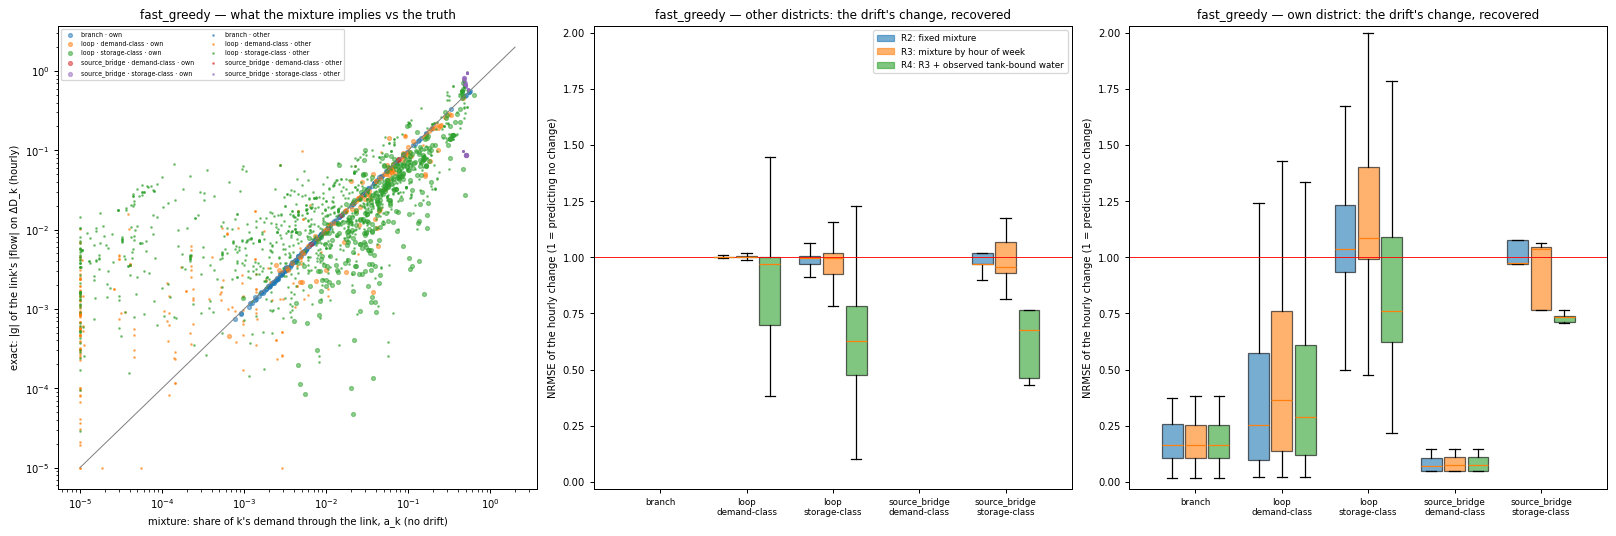

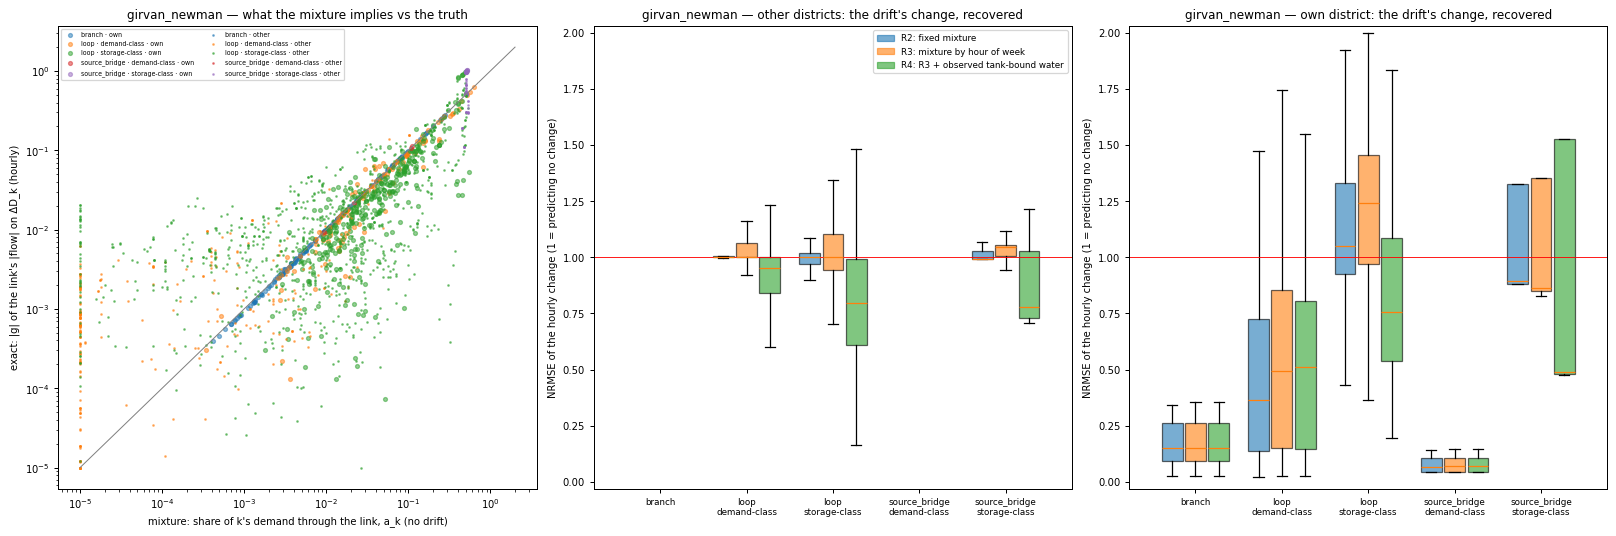

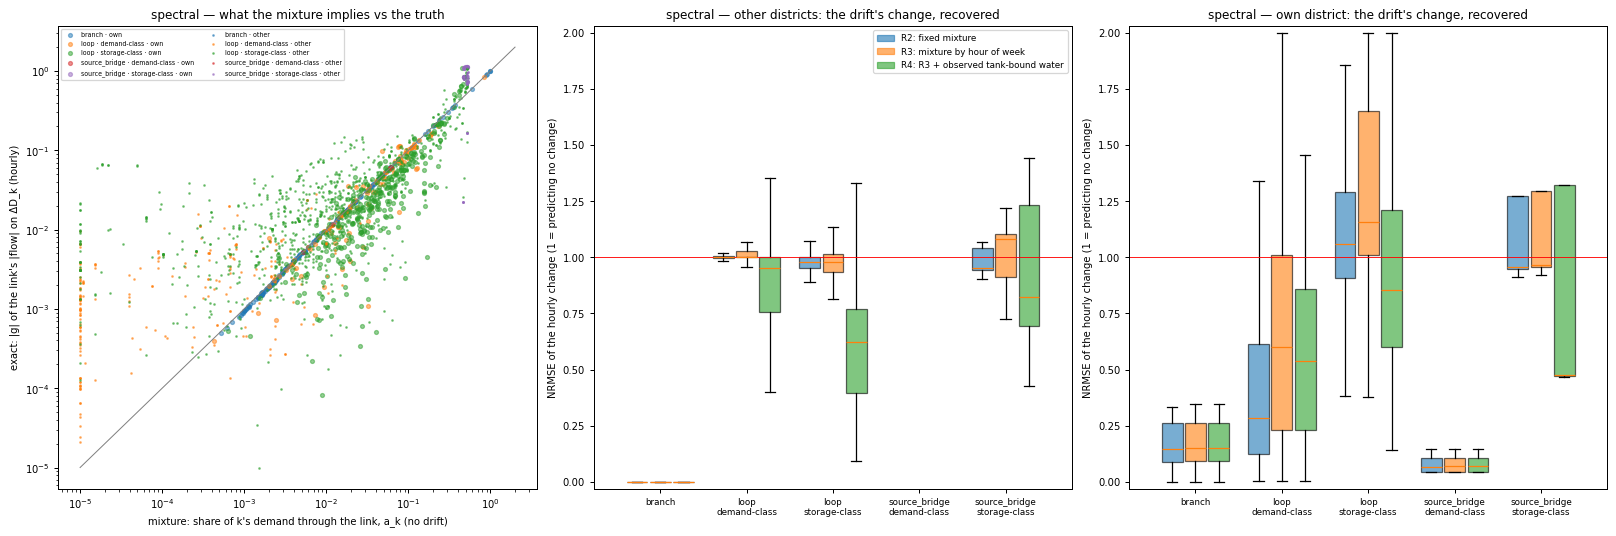

**Per drift world** (cells with rms change ≥ 0.001 L/s; median NRMSE of the change, and share of cells the mixture predicts better than 'no change')

cells  R2 med  R3 med  R4 med  R2 < 1  R3 < 1  R4 < 1
districting   k          own   group                                                                               
fast_greedy   District_A False loop · demand-class               64   1.000   1.008   0.990   0.297   0.156   0.734
                               loop · storage-class             148   0.998   1.037   0.785   0.716   0.047   0.926
                               source_bridge · storage-class      4   1.159   1.175   1.230   0.000   0.000   0.000
                         True  branch                            29   0.233   0.239   0.239   1.000   1.000   1.000
                               loop · demand-class               20   0.326   0.422   0.449   0.700   0.750   0.850
                               loop · storage-class             170   1.091   1.052   0.738   0.276   0.212   0.829
                               source_bridge · storage-class      8   0.973   1.042   0.721   1.000   0.000   1.000
              District_B False loop · demand-class               45   1.000   1.000   1.000   0.200   0.200   0.711
                               loop · storage-class             226   1.002   1.001   0.763   0.230   0.389   0.823
                               source_bridge · storage-class     12   0.971   1.069   0.764   0.667   0.000   0.667
                         True  branch                            54   0.187   0.190   0.190   1.000   1.000   1.000
                               loop · demand-class               37   0.308   0.609   0.545   0.838   0.811   0.892
                               loop · storage-class              92   0.947   1.731   1.282   0.554   0.217   0.315
                               source_bridge · demand-class       4   0.071   0.073   0.073   1.000   1.000   1.000
              District_C False loop · demand-class               58   1.000   1.000   1.000   0.379   0.328   0.672
                               loop · storage-class             304   0.943   0.886   0.567   0.757   0.740   0.931
                               source_bridge · storage-class      8   0.900   0.814   0.469   1.000   1.000   1.000
                         True  branch                            57   0.130   0.131   0.131   1.000   1.000   1.000
                               loop · demand-class               23   0.085   0.147   0.149   0.913   0.957   1.000
                               loop · storage-class              14   1.180   1.088   0.819   0.143   0.429   0.857
                               source_bridge · storage-class      4   1.077   0.765   0.736   0.000   1.000   1.000
              District_D False loop · demand-class               55   1.000   1.000   0.699   0.364   0.655   0.964
                               loop · storage-class             276   1.000   0.976   0.496   0.717   0.920   0.996
                               source_bridge · storage-class     12   0.973   0.956   0.457   0.667   1.000   1.000
                         True  branch                            25   0.152   0.152   0.152   1.000   1.000   1.000
                               loop · demand-class               19   0.443   0.323   0.208   0.789   1.000   1.000
                               loop · storage-class              42   0.917   0.961   0.593   0.619   0.548   1.000
girvan_newman District_A False loop · demand-class               57   1.000   1.061   0.884   0.333   0.000   0.877
                               loop · storage-class             105   0.984   1.083   0.789   0.867   0.000   0.848
                               source_bridge · storage-class      8   0.927   1.111   0.777   1.000   0.000   1.000
                         True  branch                            70   0.134   0.137   0.137   1.000   1.000   1.000
                               loop · demand-class               43   0.425   0.757   0.742   0.744   0.651   0.721
                               loop · storage-class             196   1.201   1.298   0.845   0.265   0.051   0.612
  

In [9]:
# D · does the no-drift mixture predict the drift's effect? (per world; cells with a real change only)
DY_MIN = 1e-3                                       # L/s: rms change below this is not drawn (no response)
if GATES_OK:
    for m in PARTS:
        q = DELT[(DELT["districting"] == m) & DELT["group"].isin(GRP) & (DELT["dy_rms"] >= DY_MIN)]
        fig, axes = plt.subplots(1, 3, figsize=(18, 6), squeeze=False)
        ax = axes[0, 0]
        gc = {gg: plt.get_cmap("tab10")(i) for i, gg in enumerate(GRP)}
        for own, mk in ((True, "o"), (False, ".")):
            for gg in GRP:
                z = q[(q["own"] == own) & (q["group"] == gg)]
                ax.scatter(z["a_static_k"].abs().clip(1e-5), z["g_mag"].abs().clip(1e-5), s=10 if own else 6, marker=mk,
                           color=gc[gg], alpha=0.5, label=f"{gg} · {'own' if own else 'other'}")
        ax.plot([1e-5, 2], [1e-5, 2], color="0.5", lw=0.8)
        ax.set(xscale="log", yscale="log", xlabel="mixture: share of k's demand through the link, a_k (no drift)",
               ylabel="exact: |g| of the link's |flow| on ΔD_k (hourly)", title=f"{m} — what the mixture implies vs the truth")
        ax.legend(fontsize=5, ncol=2)
        for c_, own in ((1, False), (2, True)):
            ax = axes[0, c_]
            z = q[q["own"] == own]
            for mi, (mod, col, _) in enumerate(MODS):
                data = [z[z["group"] == gg][f"dnrmse_{mod}"].dropna().clip(0, 2) for gg in GRP]
                bp = ax.boxplot(data, positions=np.arange(len(GRP)) + (mi - 1) * 0.27, widths=0.24, showfliers=False,
                                patch_artist=True)
                for b in bp["boxes"]:
                    b.set(facecolor=col, alpha=0.6)
            ax.axhline(1, color="r", lw=0.7)
            ax.set_xticks(range(len(GRP)), [gg.replace(" · ", "\n") for gg in GRP], fontsize=7)
            ax.set(ylim=(-0.03, 2.03), ylabel="NRMSE of the hourly change (1 = predicting no change)",
                   title=f"{m} — {'own district' if own else 'other districts'}: the drift's change, recovered")
        axes[0, 1].legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.6, label=f"{mod}: {t}") for mod, c, t in MODS],
                          fontsize=7)
        fig.tight_layout(); plt.show()
    display(Markdown(f"**Per drift world** (cells with rms change ≥ {DY_MIN} L/s; median NRMSE of the change, and share of "
                     "cells the mixture predicts better than 'no change')"))
    z = DELT[DELT["group"].isin(GRP) & (DELT["dy_rms"] >= DY_MIN)]
    display(z.groupby(["districting", "k", "own", "group"]).agg(
        cells=("dy_rms", "size"), **{f"{mod} med": (f"dnrmse_{mod}", "median") for mod, _, _ in MODS},
        **{f"{mod} < 1": (f"dnrmse_{mod}", lambda x: float((x < 1).mean())) for mod, _, _ in MODS}).round(3))

## C · Composition revisited

Every link (no drift, init): the reservoir and the unaccounted shares apart (M4 in epanet_gt v3 drew them as one dark
segment), the hour-of-week swing of the own share for every link (epanet_gt had it only for the placed sensors) and flow
reversals. Saved in `composition_all` — the swing and the composition vector are inputs to the selection notebook.

**Links whose water ends in a reservoir or is unaccounted** (share ≥ 5 %; `above_floor`: volume ≥ 1e-3 × median, where the E1 gate applies)

,districting,element,group,placed,volume,above_floor,storage_share,reservoir_share,unaccounted_share,flip_share


**Hour-of-week swing of the own share** (q95 − q05 over the 7·24 hours; renormalised over districts as in epanet_gt M2, and raw, i.e. with tank-bound water in the denominator), and flow reversals

links  swing_renorm_med  swing_renorm_q90  swing_raw_med  storage_share_med  flip_share_med  links_with_reversals
districting   group                                                                                                                                           
fast_greedy   branch                           165             0.000             0.000          0.000              0.000           0.000                     0
              loop · demand-class              101             0.096             0.810          0.612              0.025           0.002                    58
              loop · storage-class             318             0.584             0.944          0.765              0.445           0.445                   304
              source_bridge · demand-class       4             0.000             0.000          0.760              0.339           0.000                     0
              source_bridge · storage-class     12             0.923             0.932          0.802              0.495           0.445                    12
girvan_newman branch                           165             0.000             0.000          0.000              0.000           0.000                     0
              loop · demand-class              118             0.338             0.942          0.852              0.107           0.000                    68
              loop · storage-class             301             0.879             0.982          0.910              0.426           0.451                   275
              source_bridge · demand-class       4             0.000             0.000          0.739              0.320           0.000                     0
              source_bridge · storage-class     12             0.892             0.987          0.791              0.480           0.451                    12
spectral      branch                           165             0.000             0.000          0.000              0.000           0.000                     0
              loop · demand-class              108             0.481             0.895          0.837              0.102           0.001                    68
              loop · storage-class             311             0.635             0.888          0.800              0.424           0.445                   291
              source_bridge · demand-class       4             0.000             0.000          0.746              0.317           0.000                     0
              source_bridge · storage-class     12             0.824             1.000          0.431              0.473           0.444                    12

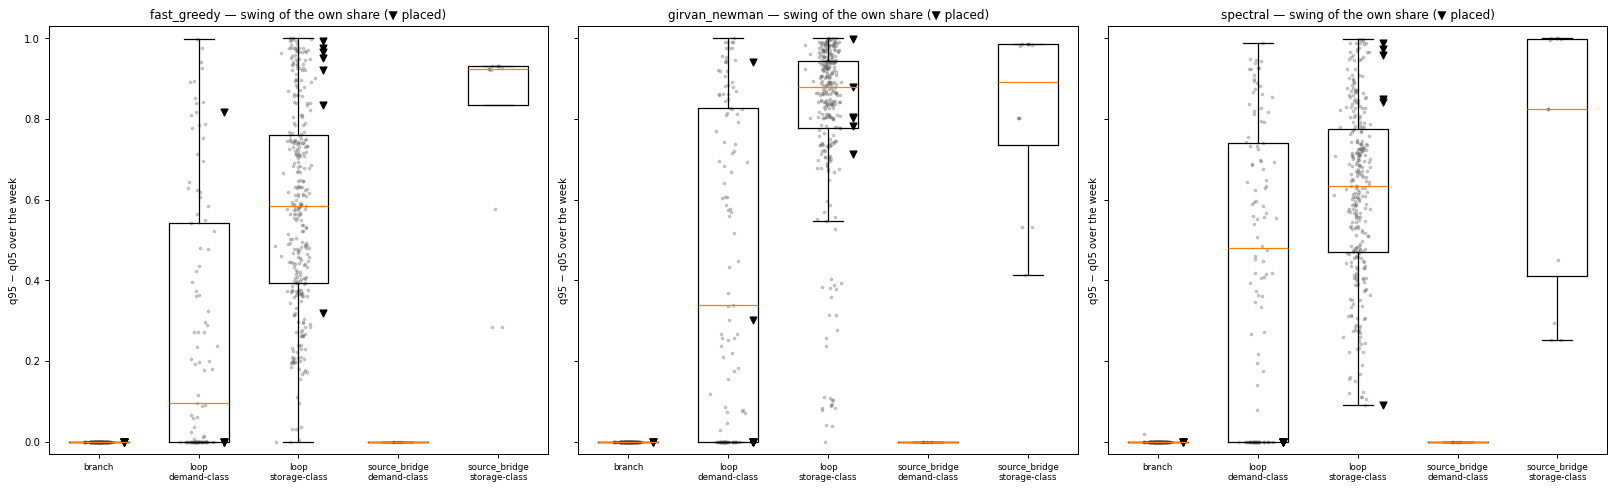

In [10]:
# C · composition of every link (no drift, init), with the reservoir and the unaccounted water apart, and the swing
if GATES_OK:
    vfl = COMPT.groupby("districting")["volume"].transform(lambda v: 1e-3 * np.median(v[v > 0]))
    C_ = COMPT.assign(above_floor=COMPT["volume"] >= vfl)
    display(Markdown("**Links whose water ends in a reservoir or is unaccounted** (share ≥ 5 %; `above_floor`: volume ≥ "
                     "1e-3 × median, where the E1 gate applies)"))
    show = ["districting", "element", "group", "placed", "volume", "above_floor", "storage_share", "reservoir_share",
            "unaccounted_share", "flip_share"]
    display(C_[(C_["reservoir_share"] >= 0.05) | (C_["unaccounted_share"] >= 0.05)][show]
            .sort_values(["districting", "unaccounted_share"], ascending=[True, False]).round(4))
    display(Markdown("**Hour-of-week swing of the own share** (q95 − q05 over the 7·24 hours; renormalised over districts "
                     "as in epanet_gt M2, and raw, i.e. with tank-bound water in the denominator), and flow reversals"))
    display(C_[C_["group"].isin(GRP)].groupby(["districting", "group"]).agg(
        links=("element", "size"), swing_renorm_med=("swing_own_renorm", "median"),
        swing_renorm_q90=("swing_own_renorm", lambda x: x.quantile(0.9)), swing_raw_med=("swing_own_raw", "median"),
        storage_share_med=("storage_share", "median"), flip_share_med=("flip_share", "median"),
        links_with_reversals=("flip_share", lambda x: int((x > 0).sum()))).round(3))
    fig, axes = plt.subplots(1, len(PARTS), figsize=(6 * len(PARTS), 5.5), squeeze=False, sharey=True)
    for ax, m in zip(axes[0], PARTS):
        z = C_[(C_["districting"] == m) & C_["group"].isin(GRP)]
        data = [z[z["group"] == gg]["swing_own_renorm"].dropna() for gg in GRP]
        ax.boxplot(data, showfliers=False, widths=0.6)
        rng = np.random.default_rng(0)
        for i_, gg in enumerate(GRP, start=1):
            zz = z[z["group"] == gg]
            ax.scatter(rng.normal(i_, 0.06, len(zz)), zz["swing_own_renorm"], s=4, alpha=0.3, color="0.4")
            pl = zz[zz["placed"]]
            ax.scatter(np.full(len(pl), i_ + 0.25), pl["swing_own_renorm"], s=30, marker="v", color="k")
        ax.set_xticks(range(1, len(GRP) + 1), [gg.replace(" · ", "\n") for gg in GRP], fontsize=7)
        ax.set(ylim=(-0.03, 1.03), title=f"{m} — swing of the own share (▼ placed)", ylabel="q95 − q05 over the week")
    fig.tight_layout(); plt.show()

## X · Channel taxonomy

Per (link $s$, drifting district $k$), final window, from epanet_gt's exact labels:

| class | rule |
|---|---|
| own | $k$ is the link's own district |
| none | label below its floor ($S<0.25$ or $N_r<0.05$, per metric) |
| transit · demand | carries $k$'s water ($m_k\ge$ `M_CARRY`) and responds through the demand channel (E2 storage share $<$ `CH_LO`) |
| transit · hub | carries $k$'s water and responds through storage (share $\ge$ `CH_LO`) |
| trace | responds, carries a trace of $k$'s water ($m_k\in$ [`M_TRACE`, `M_CARRY`)) |
| reroute · demand | carries none of $k$'s water ($m_k<$ `M_TRACE`) yet responds through the demand channel — $k$'s demand changes how the sources split elsewhere (head redistribution with the hub held) |
| hub only | carries none of $k$'s water and responds through storage |
| undefined | no E2 split or no composition |

$m_k$ = share of $k$'s demand in the link's water (no drift, init; renormalised over districts). β (dose exponent) is
carried as an attribute, not a gate. The floors and thresholds are definitions. Saved in `taxonomy` for S and Nr.

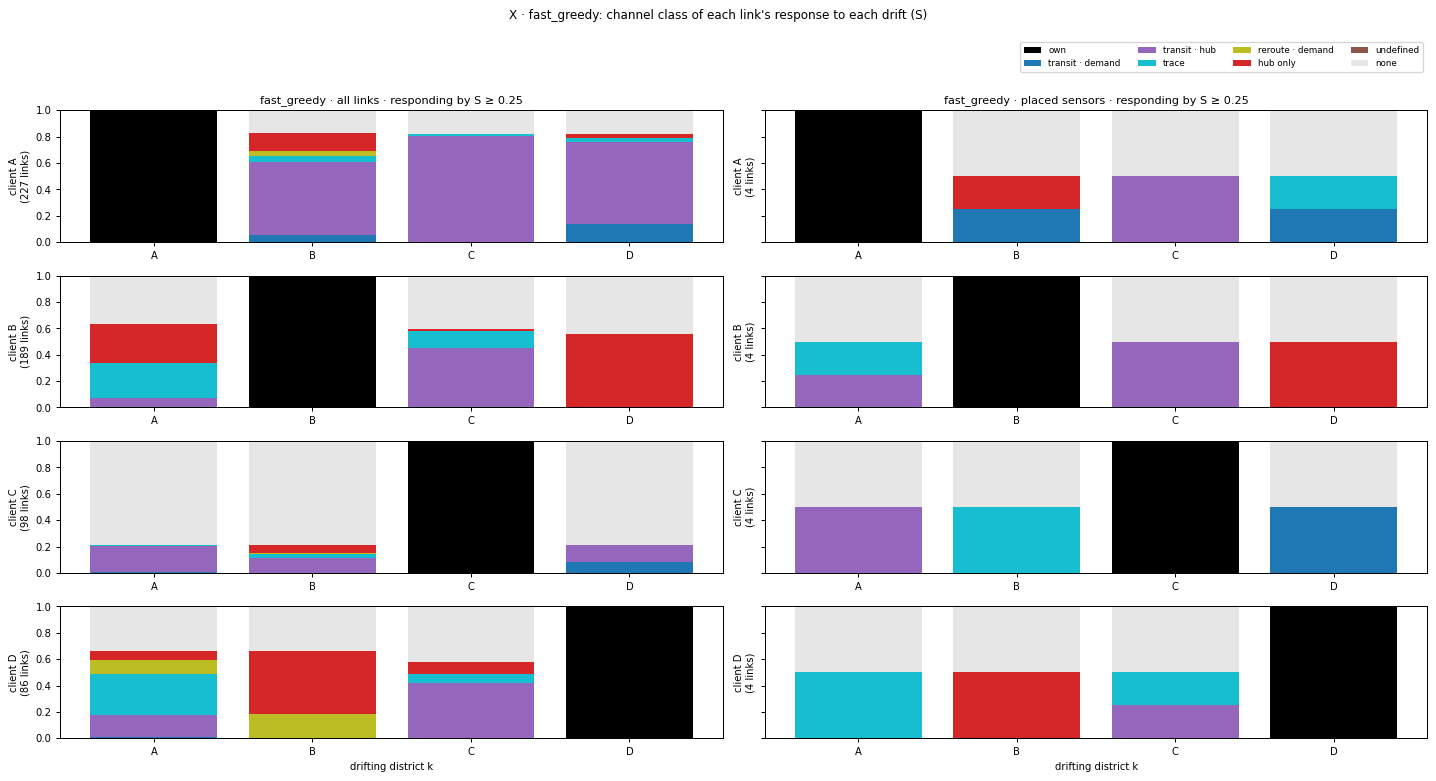

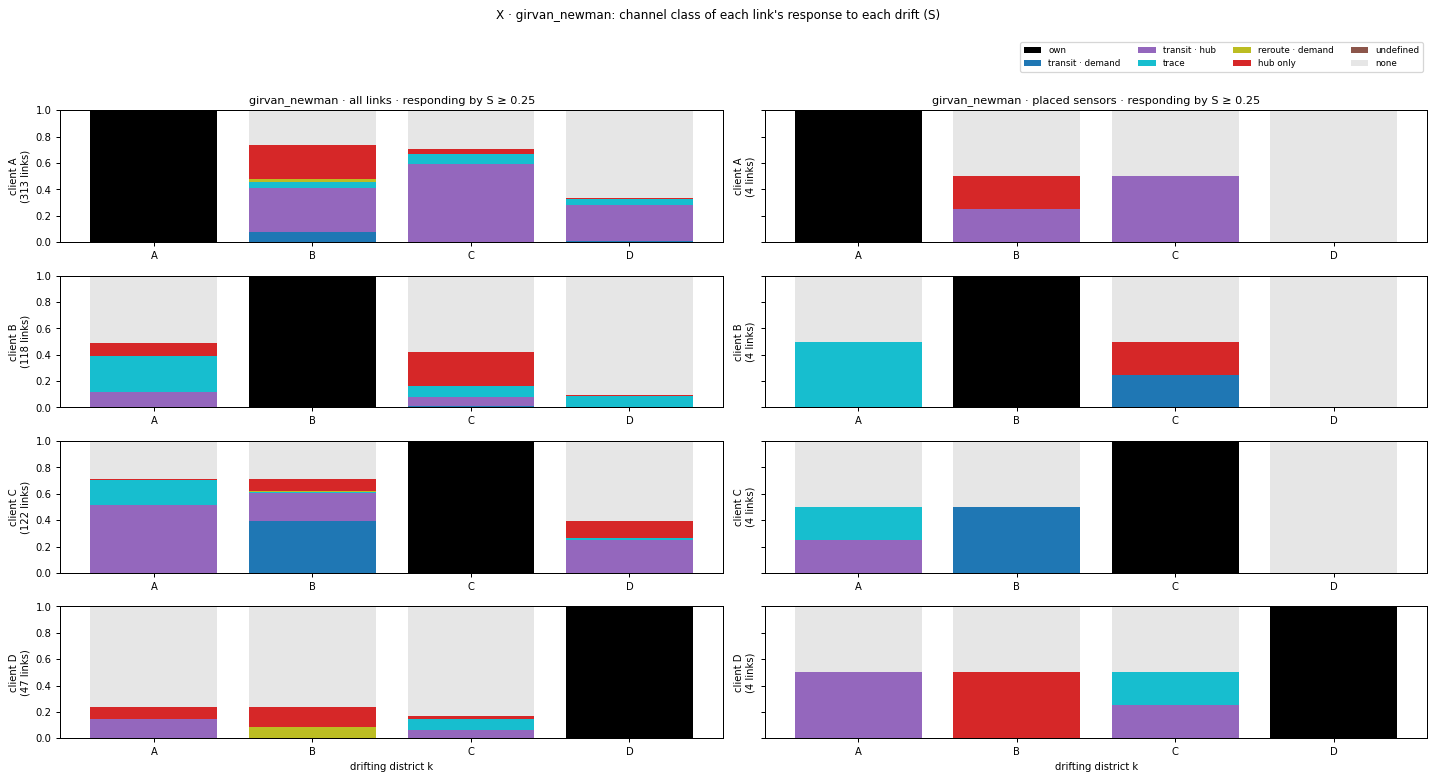

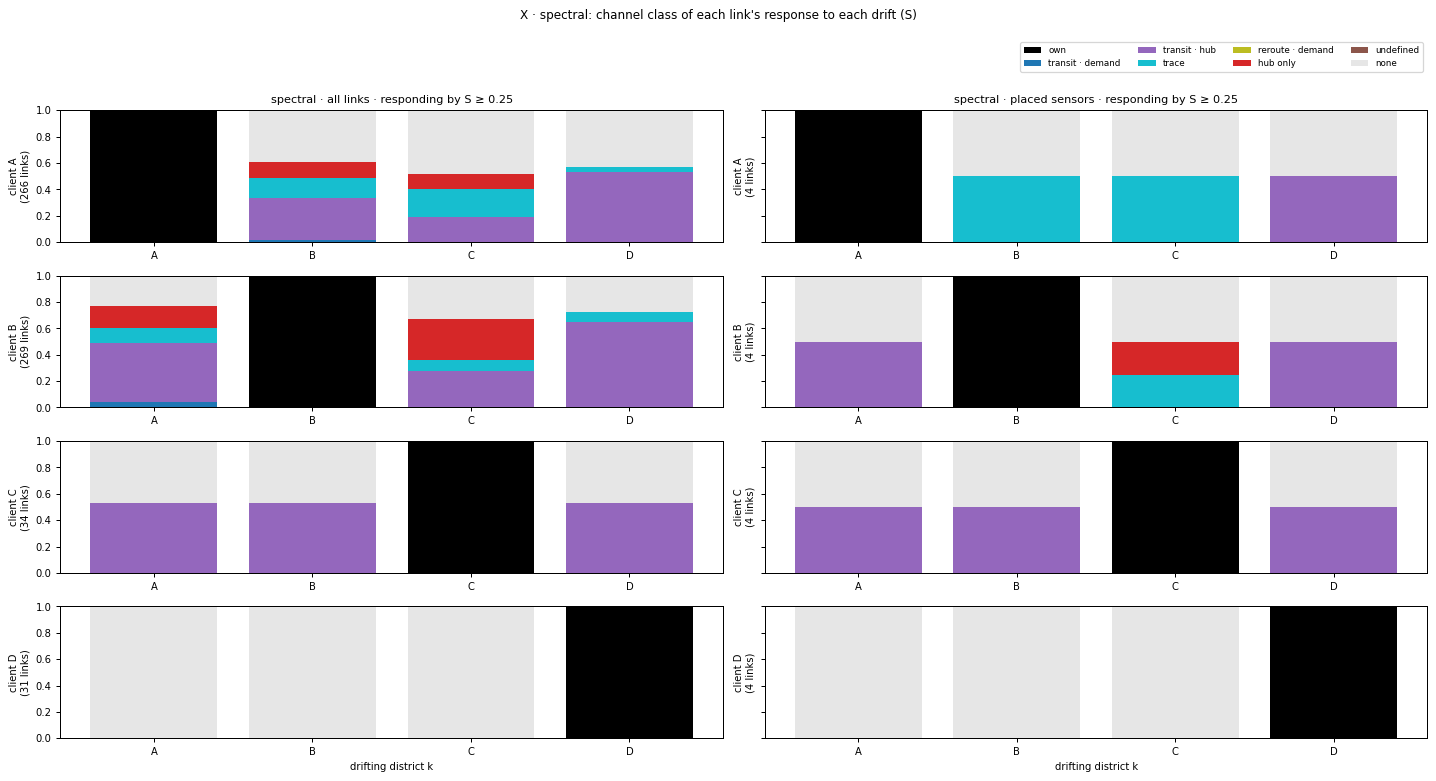

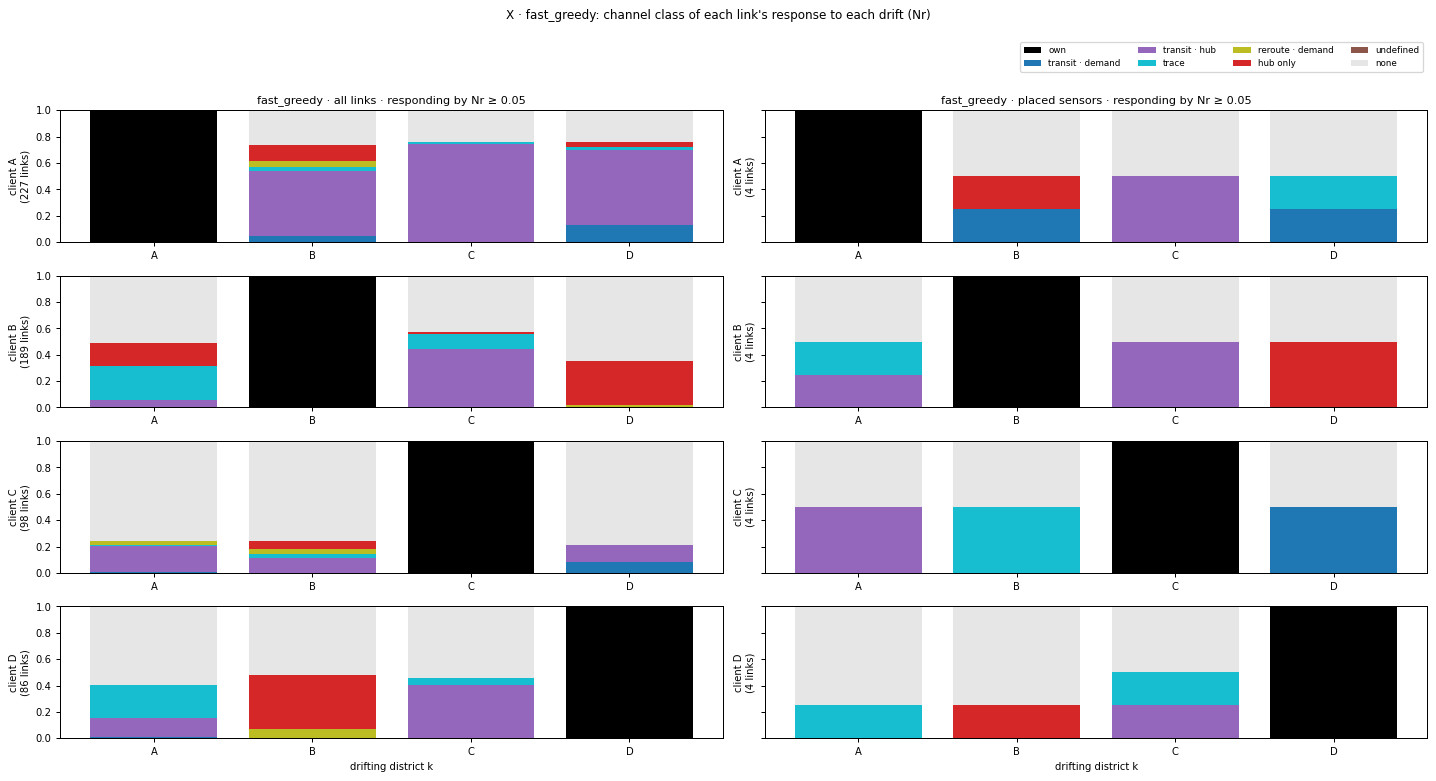

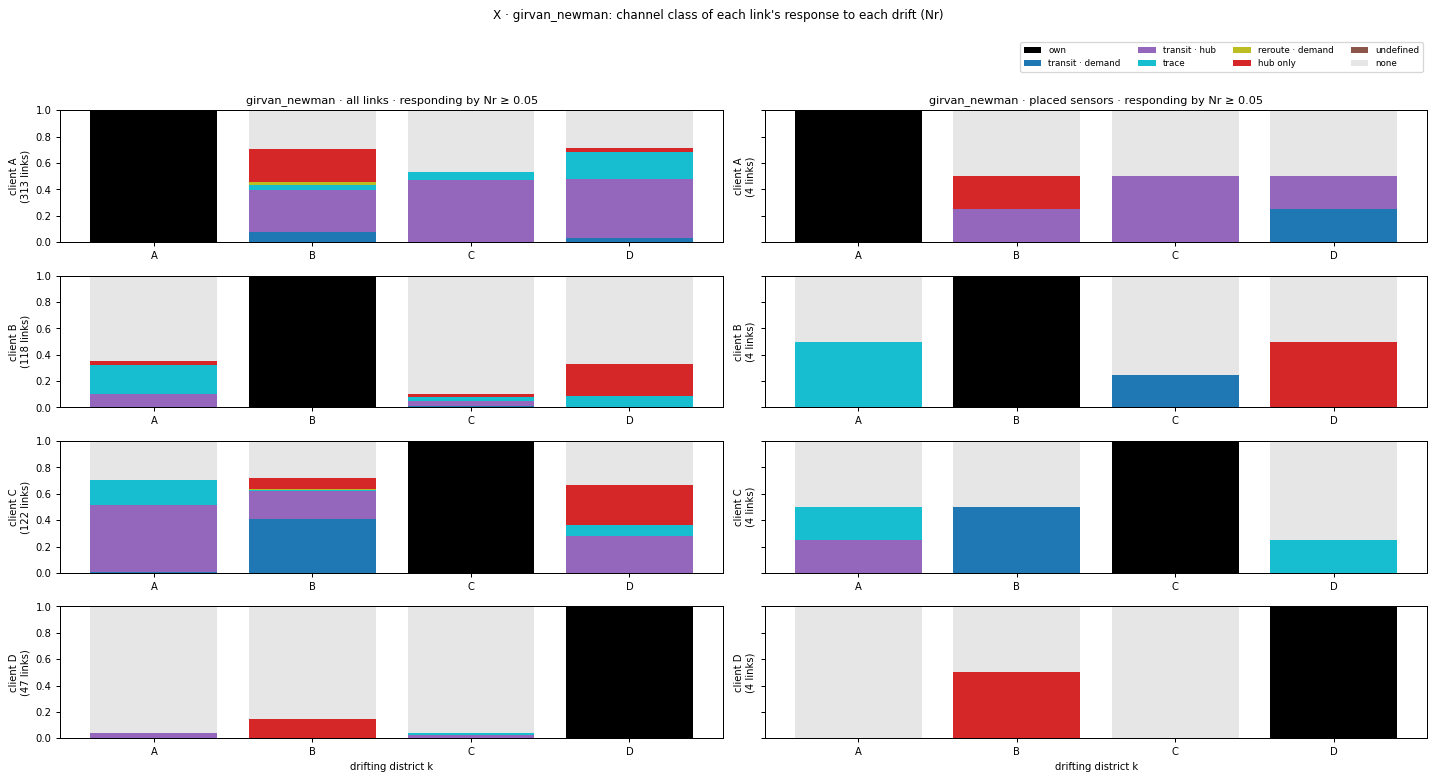

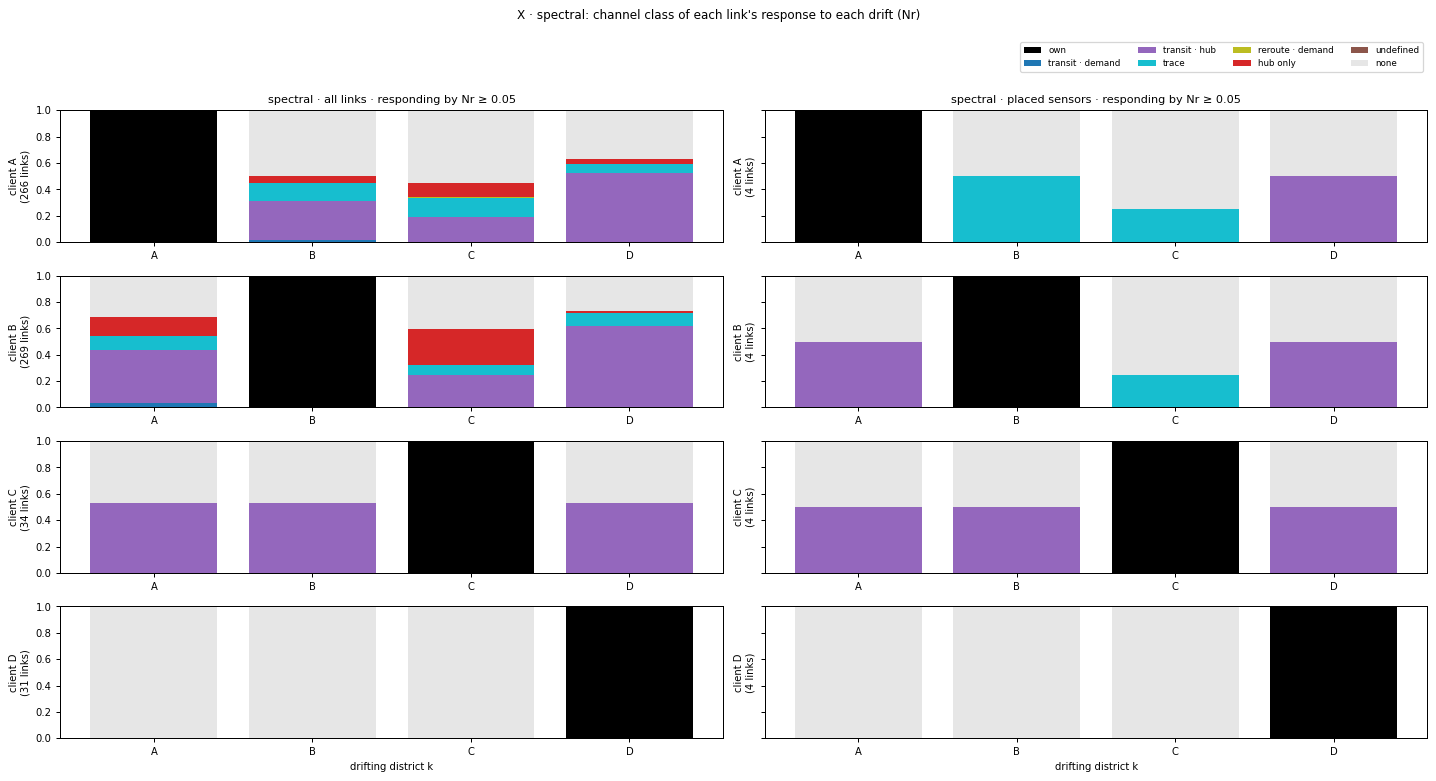

**Off-diagonal cells per class** (share of cells; median β, storage share and m_k)

cells  placed  beta_med  sto_share_med  m_k_med  share
districting   metric cls                                                                     
fast_greedy   Nr     hub only            178       4     0.614          0.469    0.001  0.099
                     none                838      26     0.015          0.535    0.000  0.466
                     reroute · demand     25       0     0.657          0.203    0.001  0.014
                     trace               115       6     0.623          0.668    0.030  0.064
                     transit · demand     52       4     0.617          0.209    0.489  0.029
                     transit · hub       592       8     0.512          0.923    0.189  0.329
              S      hub only            263       5     0.569          0.480    0.000  0.146
                     none                675      24     0.007          0.546    0.000  0.375
                     reroute · demand     36       0     0.583          0.255    0.000  0.020
                     trace               131       7     0.622          0.668    0.029  0.073
                     transit · demand     55       4     0.621          0.228    0.488  0.031
                     transit · hub       640       8     0.512          0.919    0.186  0.356
girvan_newman Nr     hub only            178       5     0.570          0.589    0.001  0.099
                     none                829      30     0.015          0.533    0.000  0.461
                     reroute · demand      8       0     0.603          0.293    0.000  0.004
                     trace               170       4     0.394          0.880    0.031  0.094
                     transit · demand     84       4     0.619          0.188    0.438  0.047
                     transit · hub       531       5     0.429          0.698    0.178  0.295
              S      hub only            177       4     0.570          0.451    0.000  0.098
                     none                873      30     0.020          0.643    0.000  0.485
                     reroute · demand     12       0     0.652          0.287    0.000  0.007
                     trace               135       4     0.438          0.752    0.029  0.075
                     transit · demand     75       3     0.622          0.181    0.467  0.042
                     transit · hub       528       7     0.430          0.520    0.179  0.293
spectral      Nr     hub only            166       0     1.280          0.571    0.002  0.092
                     none                787      32     0.013          0.548    0.000  0.437
                     reroute · demand      2       0     0.970          0.216    0.000  0.001
                     trace               167       4     1.307          0.627    0.029  0.093
                     transit · demand     15       0     1.040          0.241    0.492  0.008
                     transit · hub       663      12     2.096          0.962    0.177  0.368
              S      hub only            191       1     1.275          0.535    0.001  0.106
                     none                714      30     0.007          0.569    0.000  0.397
                     trace               178       5     1.301          0.547    0.027  0.099
                     transit · demand     17       0     1.025          0.234    0.570  0.009
                     transit · hub       700      12     1.915          0.956    0.178  0.389

In [11]:
# X · channel taxonomy of every (link, drifting district) cell, final window, from epanet_gt's exact labels
CLS = ["own", "transit · demand", "transit · hub", "trace", "reroute · demand", "hub only", "undefined", "none"]
CLS_COL = {"own": "#000000", "transit · demand": "#1f77b4", "transit · hub": "#9467bd", "trace": "#17becf",
           "reroute · demand": "#bcbd22", "hub only": "#d62728", "undefined": "#8c564b", "none": "#e6e6e6"}


def taxonomy(df, metric):
    resp = (df[metric] >= FLOOR[metric]).to_numpy()
    sh = df["sto_share"].to_numpy(float) if "sto_share" in df.columns else np.full(len(df), np.nan)
    ch = np.select([sh < CH_LO, sh > CH_HI, np.isfinite(sh)], ["demand", "storage", "both"], "undefined")
    mk = df["m_k"].to_numpy(float) if "m_k" in df.columns else np.full(len(df), np.nan)
    carry = np.select([mk >= M_CARRY, mk >= M_TRACE, np.isfinite(mk)], ["carrier", "trace", "non-carrier"], "unknown")
    return np.select([df["own"].to_numpy(bool), ~resp, (ch == "undefined") | (carry == "unknown"),
                      (carry == "carrier") & (ch == "demand"), carry == "carrier", carry == "trace", ch == "demand"],
                     ["own", "none", "undefined", "transit · demand", "transit · hub", "trace", "reroute · demand"],
                     "hub only")


TXB = LBg[LBg["period"] == "final"].copy()
keep_ = [c for c in ("districting", "k", "element", "home", "own", "topo", "storage", "placed", "S", "Nr", "m_k",
                     "sto_share", "beta") if c in TXB.columns]
TAX = pd.concat([TXB[keep_].assign(metric=x, cls=taxonomy(TXB, x)) for x in ("S", "Nr")], ignore_index=True)
TAX["group"] = [group_of(t, s) for t, s in zip(TAX["topo"], TAX["storage"])]
TAX.to_parquet(OUT / "taxonomy.parquet", index=False)

for x in ("S", "Nr"):
    for m in PARTS:
        q = TAX[(TAX["districting"] == m) & (TAX["metric"] == x)]
        js, ks = sorted(q["home"].dropna().unique()), sorted(q["k"].unique())
        fig, axes = plt.subplots(len(js), 2, figsize=(16, 1.9 * len(js) + 1), squeeze=False, sharey=True)
        for c_, (scope, qq) in enumerate((("all links", q), ("placed sensors", q[q["placed"]]))):
            for r_, j in enumerate(js):
                ax = axes[r_, c_]
                sh = qq[qq["home"] == j].groupby("k")["cls"].value_counts(normalize=True).unstack().reindex(index=ks, columns=CLS).fillna(0)
                bottom = np.zeros(len(ks))
                for cl in CLS:
                    ax.bar(range(len(ks)), sh[cl], bottom=bottom, color=CLS_COL[cl], width=0.8, label=cl)
                    bottom += sh[cl].to_numpy()
                n_ = qq[qq["home"] == j]["element"].nunique()
                ax.set_xticks(range(len(ks)), [k.replace("District_", "") for k in ks])
                ax.set(ylim=(0, 1), ylabel=f"client {j.replace('District_', '')}\n({n_} links)")
                if r_ == 0:
                    ax.set_title(f"{m} · {scope} · responding by {x} ≥ {FLOOR[x]:g}", fontsize=9)
            axes[-1, c_].set_xlabel("drifting district k")
        axes[0, 1].legend(fontsize=7, ncol=4, loc="upper right", bbox_to_anchor=(1.0, 1.55))
        fig.suptitle(f"X · {m}: channel class of each link's response to each drift ({x})", y=1.0)
        fig.tight_layout(); plt.show()

display(Markdown("**Off-diagonal cells per class** (share of cells; median β, storage share and m_k)"))
off = TAX[~TAX["own"]]
display(off.groupby(["districting", "metric", "cls"]).agg(
    cells=("element", "size"), placed=("placed", "sum"), beta_med=("beta", "median"), sto_share_med=("sto_share", "median"),
    m_k_med=("m_k", "median")).join(off.groupby(["districting", "metric"])["cls"].value_counts(normalize=True).rename("share"))
    .round(3))

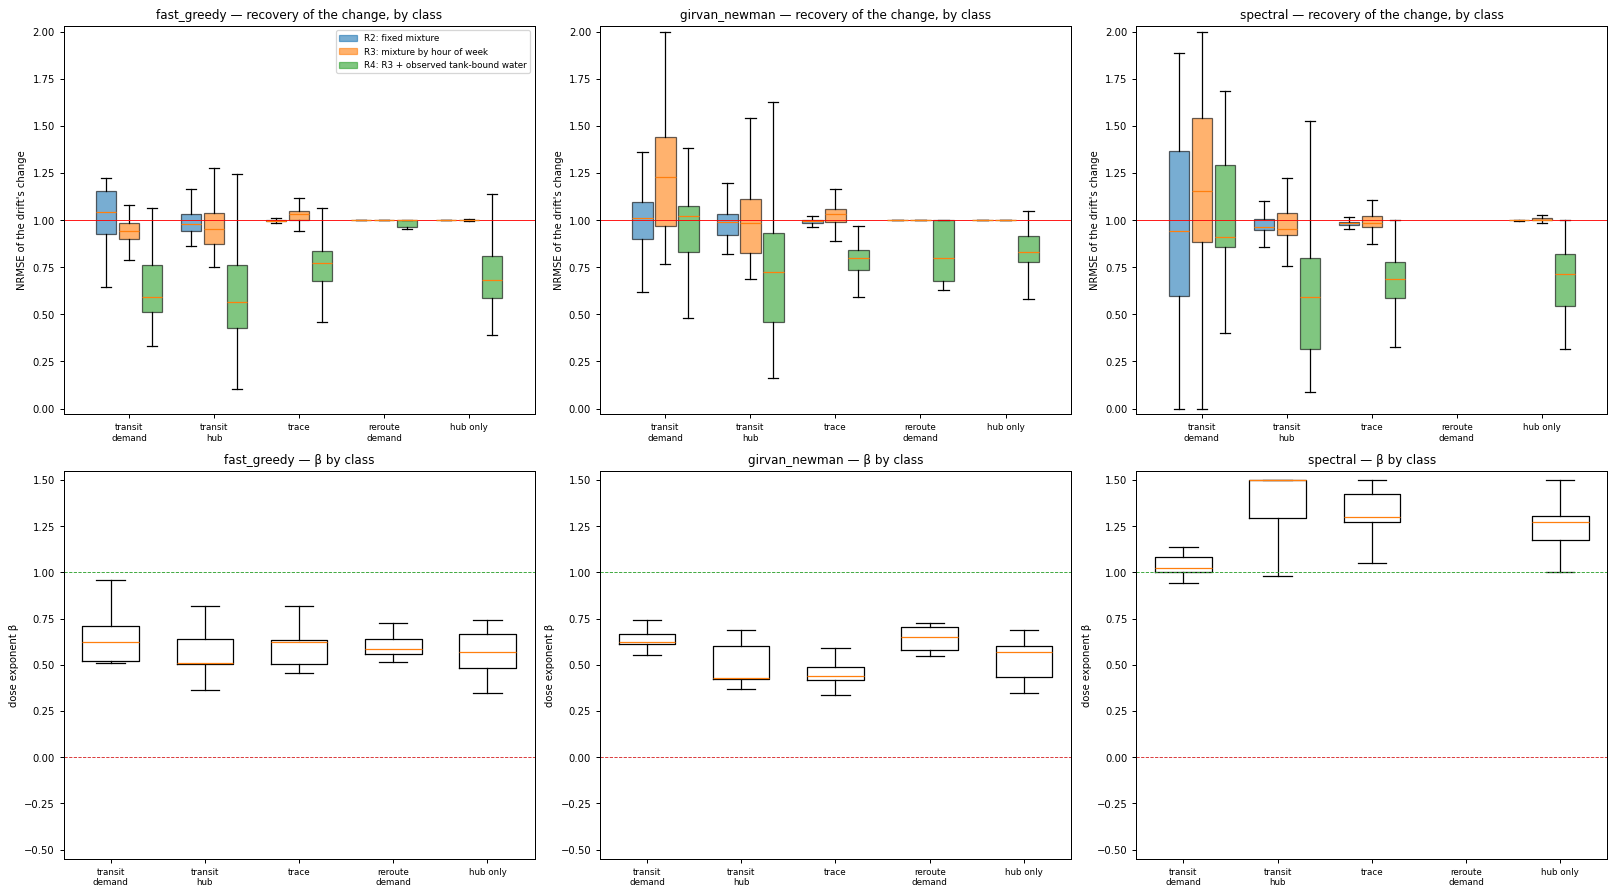

cells  R2 med  R3 med  R4 med  beta_med
districting   cls                                                      
fast_greedy   hub only            263   1.000   1.000   0.683     0.569
              reroute · demand     36   1.000   1.000   1.000     0.583
              trace               131   0.996   1.031   0.771     0.622
              transit · demand     55   1.044   0.944   0.594     0.621
              transit · hub       640   0.981   0.952   0.568     0.512
girvan_newman hub only            177   1.000   1.000   0.832     0.570
              reroute · demand     12   1.000   1.000   0.800     0.652
              trace               135   0.994   1.032   0.800     0.438
              transit · demand     75   1.011   1.229   1.021     0.622
              transit · hub       528   0.992   0.987   0.727     0.430
spectral      hub only            191   1.000   1.000   0.714     1.275
              trace               178   0.986   0.986   0.689     1.301
              transit · demand     17   0.941   1.155   0.911     1.025
              transit · hub       700   0.962   0.955   0.590     1.915

In [12]:
# X · does the channel class tell which responses a mixture can recover? (off-diagonal cells, shape metric)
if GATES_OK:
    J = TAX[(TAX["metric"] == "S") & ~TAX["own"]].merge(
        DELT[["districting", "k", "element", "dy_rms"] + [f"dnrmse_{m_}" for m_, _, _ in MODS]],
        on=["districting", "k", "element"], how="left")
    J = J[J["cls"] != "none"]
    cls_ = [c for c in CLS if c in set(J["cls"]) and c != "own"]
    fig, axes = plt.subplots(2, len(PARTS), figsize=(6 * len(PARTS), 10), squeeze=False)
    for c_, m in enumerate(PARTS):
        z = J[J["districting"] == m]
        ax = axes[0, c_]
        for mi, (mod, col, _) in enumerate(MODS):
            bp = ax.boxplot([z[z["cls"] == cl][f"dnrmse_{mod}"].dropna().clip(0, 2) for cl in cls_],
                            positions=np.arange(len(cls_)) + (mi - 1) * 0.27, widths=0.24, showfliers=False, patch_artist=True)
            for b in bp["boxes"]:
                b.set(facecolor=col, alpha=0.6)
        ax.axhline(1, color="r", lw=0.7)
        ax.set_xticks(range(len(cls_)), [c.replace(" · ", "\n") for c in cls_], fontsize=7)
        ax.set(ylim=(-0.03, 2.03), ylabel="NRMSE of the drift's change", title=f"{m} — recovery of the change, by class")
        ax = axes[1, c_]
        ax.boxplot([z[z["cls"] == cl]["beta"].dropna().clip(-0.5, 1.5) for cl in cls_], showfliers=False, widths=0.6)
        ax.axhline(1, color="#2ca02c", lw=0.7, ls="--"); ax.axhline(0, color="#d62728", lw=0.7, ls="--")
        ax.set_xticks(range(1, len(cls_) + 1), [c.replace(" · ", "\n") for c in cls_], fontsize=7)
        ax.set(ylim=(-0.55, 1.55), ylabel="dose exponent β", title=f"{m} — β by class")
    axes[0, 0].legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.6, label=f"{mod}: {t}") for mod, c, t in MODS],
                      fontsize=7)
    fig.tight_layout(); plt.show()
    display(J.groupby(["districting", "cls"]).agg(cells=("element", "size"),
                                                  **{f"{mod} med": (f"dnrmse_{mod}", "median") for mod, _, _ in MODS},
                                                  beta_med=("beta", "median")).round(3))

## Files

`recovery` (link × window × model: NRMSE, bias, ρ_shape), `recovery_delta` (link × drift world: NRMSE_Δ and corr per
model, a_k, exact g, rms change), `composition_all` (link: shares per district / tanks / reservoir / unaccounted, volume,
swing, flip share), `taxonomy` (link × drift world × metric: class), `rec_gates`, `fit__<partition>.npz` (weights),
`weeks__<partition>.npz` (saved weeks), `nodrift__<partition>.npz` (the no-drift city, all links, cached),
`recovery_run.json`.